# Phase 1: exploration of the S8 synthetic sample

Checks the sample against the Annex I data dictionary, recovers the Scorecard
arithmetic and describes the inputs, the administrative flags and the eligibility
outcome. Tables go to `reports/tables/`, figures to `reports/figures/` and headline
numbers to `reports/key_stats.json`; the written report is
`reports/01_data_exploration.md`. Every result describes the synthetic sample, not
the real operation.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "scorecard.py").exists()
)
sys.path.insert(0, str(ROOT))

In [2]:
import itertools
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

from src import scorecard
from src.charts import plot_counts, plot_rates
from src.data_dictionary import (
    ADMIN_FLAGS,
    AGGREGATED_SCORES,
    COLUMN_GROUPS,
    DEMOGRAPHIC_FACTORS,
    ENGLISH_NAMES,
    FACTORS,
    HOUSEHOLD_ATTRIBUTES,
    INCLUSION_STATUSES,
    INTERVIEW_RECORD,
    NEEDS_FACTORS,
    OUTCOMES,
    VALUE_LABELS,
)
from src.dataset import load_sample, to_english
from src.descriptive import SMALL_GROUP_N, correlation_ratio, cramers_v, rate_table
from src.integrity import (
    blank_pattern_check,
    factor_level_check,
    range_check,
    target_rule_mismatches,
    value_count_check,
)
from src.plot_style import (
    BLUE,
    CATEGORY_COLORS,
    INK,
    INK_SECONDARY,
    MUTED,
    ORANGE,
    SEQUENTIAL,
    SURFACE,
    apply_style,
)
from src.reporting import save_figure, save_table, update_key_stats

SEED = 0
# Round final-score cutpoints that sit in the same intervals as the index cutpoints.
ALTERNATIVE_FINAL_CUTPOINTS = (24.5, 31.2, 52.0)

rng = np.random.default_rng(SEED)
apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print(f"python {platform.python_version()}")
for module in (np, pd, scipy, matplotlib, sklearn):
    print(f"{module.__name__} {module.__version__}")

python 3.12.2
numpy 2.5.3
pandas 3.0.6
scipy 1.18.1
matplotlib 3.11.2
sklearn 1.9.1


In [3]:
raw = load_sample()
raw.shape

(1900, 26)

## 1. Integrity

Types, value sets and counts against Annex I, the pattern of blank cells and
duplicates.

In [4]:
group_of = {
    column: group for group, columns in COLUMN_GROUPS.items() for column in columns
}
column_overview = pd.DataFrame(
    {
        "column": raw.columns,
        "english_name": raw.columns.map(ENGLISH_NAMES),
        "group": raw.columns.map(group_of),
        "dtype": raw.dtypes.astype(str).to_numpy(),
        "blank": raw.isna().sum().to_numpy(),
        "distinct_values": raw.nunique().to_numpy(),
    }
)
save_table(column_overview, "integrity_columns")

,column,english_name,group,dtype,blank,distinct_values
0,month,Month,Interview record,str,0,14
1,Elegibilidad,Eligibility status,Outcome,str,0,6
2,Vulnerability_Category,Vulnerability category,Aggregated score,str,0,4
3,Demographics.HH.Head,Head of household,Scorecard factor score,float64,0,4
4,Demographics.Language,Language barrier,Scorecard factor score,float64,0,3
5,Demographics.Profiles,Specific needs,Scorecard factor score,float64,0,4
6,Demographics.Documentation,Documentation,Scorecard factor score,float64,0,3
7,Needs_and_Coping.BasicNeeds,Basic needs,Scorecard factor score,float64,0,2
8,Needs_and_Coping.Housing,Housing,Scorecard factor score,float64,0,4
9,Needs_and_Coping.Neg.mechanism,Negative coping,Scorecard factor score,float64,0,3


In [5]:
value_counts = save_table(value_count_check(raw), "integrity_value_counts")
value_counts["match"].value_counts()

match
True    42
Name: count, dtype: int64

In [6]:
factor_levels = save_table(factor_level_check(raw), "integrity_factor_levels")
factor_levels

,factor,documented_levels,observed_levels,n_levels,match
0,Head of household,"1.00, 1.60, 2.07, 2.70","1.00, 1.60, 2.07, 2.70",4,True
1,Language barrier,"1.00, 1.53, 2.05","1.00, 1.53, 2.05",3,True
2,Specific needs,"1.00, 1.25, 2.58, 3.25","1.00, 1.25, 2.58, 3.25",4,True
3,Documentation,"1.00, 1.56, 2.13","1.00, 1.56, 2.13",3,True
4,Basic needs,"1.00, 1.78","1.00, 1.78",2,True
5,Housing,"1.00, 1.50, 2.12, 2.82","1.00, 1.50, 2.12, 2.82",4,True
6,Negative coping,"1.00, 1.79, 2.58","1.00, 1.79, 2.58",3,True
7,Dependency,"1.00, 1.04, 1.74, 2.54","1.00, 1.04, 1.74, 2.54",4,True


In [7]:
ranges = save_table(range_check(raw), "integrity_numeric_ranges")
ranges

,column,statistic,documented,observed,match
0,Final score,min,0.00,0.000000,True
1,Final score,max,81.10,81.126802,True
2,Final score,mean,27.70,27.742527,True
3,Demographics score,min,0.00,0.000000,True
4,Demographics score,max,43.80,43.805174,True
5,Demographics score,mean,8.10,8.072326,True
6,Needs and coping score,min,0.00,0.000000,True
7,Needs and coping score,max,50.00,50.000000,True
8,Needs and coping score,mean,20.10,20.055843,True
9,Vulnerability index,min,2.00,2.000000,True


In [8]:
blank_pattern = save_table(blank_pattern_check(raw), "integrity_blank_pattern")
blank_pattern

,column,blank,blank_single_person,filled_single_person,single_person_households
0,Sex of household head,925,925,0,925
1,Sole carer,925,925,0,925
2,Asylum procedure flag,960,474,451,925
3,UNHCR field office,21,5,920,925


Blanks in the asylum flag and the office are not tied to household size, so their
share is compared across months, offices and the eligibility outcome.

In [9]:
data = to_english(raw)
blank_by_group = pd.concat(
    [
        rate_table(raw[column].isna(), data[grouping]).assign(
            blank_column=ENGLISH_NAMES[column], grouping=ENGLISH_NAMES[grouping]
        )
        for column, grouping in [
            ("ScoreCOMAR_PIL", "month"),
            ("ScoreCOMAR_PIL", "OficinaACNUR"),
            ("ScoreCOMAR_PIL", "EligibilityTarget"),
            ("OficinaACNUR", "month"),
        ]
    ]
)
blank_by_group = blank_by_group[
    [
        "blank_column",
        "grouping",
        "group",
        "n",
        "count",
        "rate",
        "ci_low",
        "ci_high",
        "small_group",
    ]
]
save_table(blank_by_group, "blank_share_by_group")
blank_by_group.groupby(["blank_column", "grouping"], sort=False)["rate"].agg(
    ["min", "max"]
)

min       max
blank_column          grouping                              
Asylum procedure flag Month               0.442029  0.633333
                      UNHCR field office  0.400000  0.715789
                      Eligibility target  0.502376  0.515222
UNHCR field office    Month               0.000000  0.033058

In [10]:
possible_combinations = int(
    np.prod([len(levels) for levels in scorecard.FACTOR_LEVELS.values()])
)
duplicates = pd.DataFrame(
    [
        ("Exact duplicate rows (all 26 columns)", int(raw.duplicated().sum())),
        ("Rows that have an exact duplicate", int(raw.duplicated(keep=False).sum())),
        (
            "Distinct combinations of the 8 factor scores",
            len(raw[FACTORS].drop_duplicates()),
        ),
        ("Possible combinations of the 8 factor scores", possible_combinations),
        (
            "Rows whose factor combination occurs more than once",
            int(raw.duplicated(FACTORS, keep=False).sum()),
        ),
    ],
    columns=["check", "value"],
)
save_table(duplicates, "duplicates")

,check,value
0,Exact duplicate rows (all 26 columns),14
1,Rows that have an exact duplicate,25
2,Distinct combinations of the 8 factor scores,493
3,Possible combinations of the 8 factor scores,13824
4,Rows whose factor combination occurs more than...,1658


In [11]:
blanks_by_column = blank_pattern.set_index("column")
single_person_blanks = all(
    blanks_by_column.loc[name, "blank"]
    == blanks_by_column.loc[name, "blank_single_person"]
    == blanks_by_column.loc[name, "single_person_households"]
    for name in ["Sex of household head", "Sole carer"]
)
target_exceptions = target_rule_mismatches(raw)
level_counts_ok = factor_levels["n_levels"].between(3, 4)
integrity_summary = pd.DataFrame(
    [
        ("Rows", "1,900", f"{len(raw):,}", len(raw) == 1900),
        ("Columns", "26", str(raw.shape[1]), raw.shape[1] == 26),
        (
            "Documented values whose count matches",
            str(len(value_counts)),
            str(value_counts["match"].sum()),
            bool(value_counts["match"].all()),
        ),
        (
            "Factors whose levels match the printed lists",
            "8",
            str(factor_levels["match"].sum()),
            bool(factor_levels["match"].all()),
        ),
        (
            "Factors with three or four levels, as the Annex I text says",
            "8",
            str(level_counts_ok.sum()),
            bool(level_counts_ok.all()),
        ),
        (
            "Score minima, maxima and means within 0.05 of Annex I",
            str(len(ranges)),
            str(ranges["match"].sum()),
            bool(ranges["match"].all()),
        ),
        (
            "Sex of head and sole carer blank exactly for single-person households",
            "925",
            str(blanks_by_column.loc["Sex of household head", "blank_single_person"]),
            single_person_blanks,
        ),
        (
            "Rows breaking INCLUSION = one of the two Elegible statuses",
            "0",
            str(target_exceptions),
            target_exceptions == 0,
        ),
        ("Exact duplicate rows", "not stated", str(duplicates.loc[0, "value"]), None),
    ],
    columns=["check", "documented", "observed", "consistent"],
)
save_table(integrity_summary, "integrity_summary")

,check,documented,observed,consistent
0,Rows,"1,900","1,900",True
1,Columns,26,26,True
2,Documented values whose count matches,42,42,True
3,Factors whose levels match the printed lists,8,8,True
4,"Factors with three or four levels, as the Anne...",8,7,False
5,"Score minima, maxima and means within 0.05 of ...",12,12,True
6,Sex of head and sole carer blank exactly for s...,925,925,True
7,Rows breaking INCLUSION = one of the two Elegi...,0,0,True
8,Exact duplicate rows,not stated,14,None


## 2. Score arithmetic

The documented relations between the final score, the two block scores, the
vulnerability index and the category.

In [12]:
demographics = raw["Demographics_Score"]
needs = raw["NeedsandCoping_Score"]
final = raw["FinalScore"]
index = raw["Vulnerability_Score"]
gap = final - (demographics + needs)
block_gap = demographics - needs
weight_d, weight_n = scorecard.block_weights()
least_squares = LinearRegression(fit_intercept=False).fit(
    np.column_stack([demographics, needs]), final
)
weighted_sum = round(weight_d, 6) * demographics + round(weight_n, 6) * needs
sum_check = pd.DataFrame(
    [
        ("Mean of final score minus block sum", gap.mean()),
        ("Standard deviation of the difference", gap.std()),
        ("Minimum difference", gap.min()),
        ("Maximum difference", gap.max()),
        ("Share of rows with absolute difference above 0.5", (gap.abs() > 0.5).mean()),
        ("Share of rows with absolute difference above 1.0", (gap.abs() > 1.0).mean()),
        ("Share of rows with absolute difference above 1.5", (gap.abs() > 1.5).mean()),
        ("Least-squares weight of the demographics score", least_squares.coef_[0]),
        ("Least-squares weight of the needs and coping score", least_squares.coef_[1]),
        ("Formula weight of the demographics score", weight_d),
        ("Formula weight of the needs and coping score", weight_n),
        (
            "Max absolute difference, final score vs weighted sum (weights to 6 decimals)",
            (final - weighted_sum).abs().max(),
        ),
        (
            "Max absolute difference, final minus block sum vs 0.032181 x block gap",
            (gap - (round(weight_d, 6) - 1) * block_gap).abs().max(),
        ),
    ],
    columns=["statistic", "value"],
)
save_table(sum_check, "final_score_vs_block_sum")

,statistic,value
0,Mean of final score minus block sum,-3.856416e-01
1,Standard deviation of the difference,4.067925e-01
2,Minimum difference,-1.474334e+00
3,Maximum difference,1.023373e+00
4,Share of rows with absolute difference above 0.5,4.400000e-01
5,Share of rows with absolute difference above 1.0,6.315789e-02
6,Share of rows with absolute difference above 1.5,0.000000e+00
7,Least-squares weight of the demographics score,1.032181e+00
8,Least-squares weight of the needs and coping s...,9.678190e-01
9,Formula weight of the demographics score,1.032181e+00


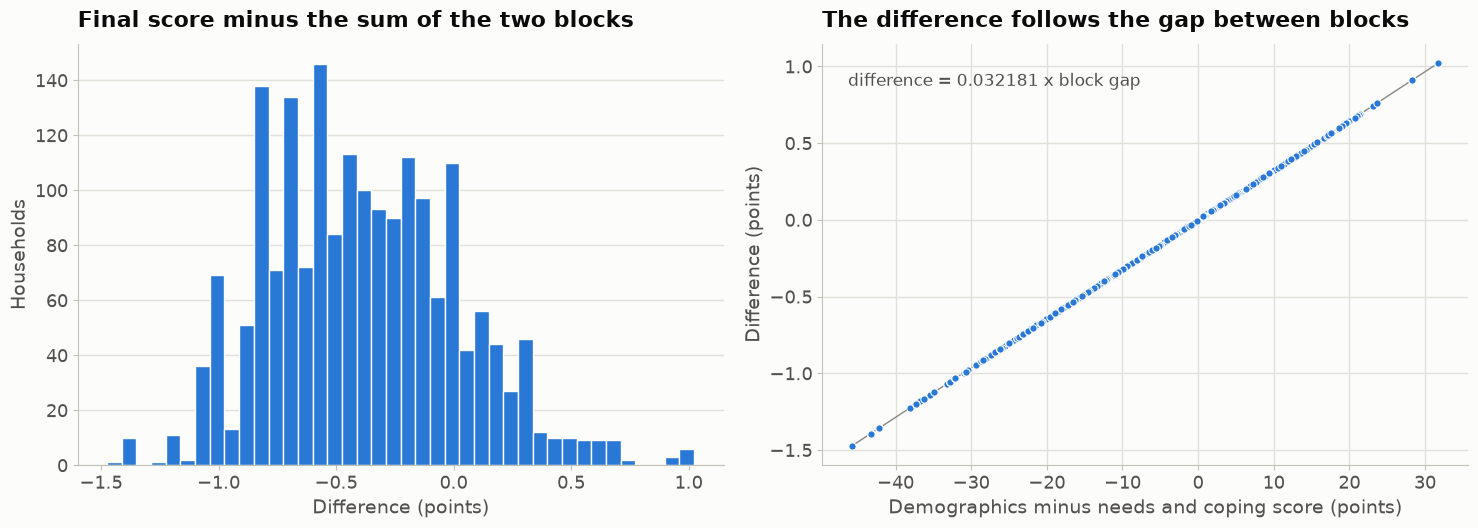

In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(15, 5.5))
left.hist(gap, bins=40, color=BLUE, edgecolor=SURFACE, linewidth=1)
left.set(
    title="Final score minus the sum of the two blocks",
    xlabel="Difference (points)",
    ylabel="Households",
)
ends = np.array([block_gap.min(), block_gap.max()])
right.plot(ends, (round(weight_d, 6) - 1) * ends, color=MUTED, linewidth=1, zorder=1)
right.scatter(
    block_gap, gap, s=28, color=BLUE, edgecolor=SURFACE, linewidth=0.8, zorder=2
)
right.annotate(
    f"difference = {round(weight_d, 6) - 1:.6f} x block gap",
    xy=(0.04, 0.9),
    xycoords="axes fraction",
    fontsize=12,
    color=INK_SECONDARY,
)
right.set(
    title="The difference follows the gap between blocks",
    xlabel="Demographics minus needs and coping score (points)",
    ylabel="Difference (points)",
)
right.grid(axis="x")
fig.tight_layout()
save_figure(fig, "final_score_minus_block_sum")

In [14]:
by_final = raw.sort_values("FinalScore", kind="stable")
index_steps = np.diff(by_final["Vulnerability_Score"].to_numpy())
affine = LinearRegression().fit(final.to_frame(), index)
top_index = scorecard.top_geometric_mean(
    DEMOGRAPHIC_FACTORS
) + scorecard.top_geometric_mean(NEEDS_FACTORS)
index_check = pd.DataFrame(
    [
        (
            "Spearman correlation with the final score",
            stats.spearmanr(final, index).statistic,
        ),
        (
            "Decreases of the index when rows are sorted by final score",
            int((index_steps < 0).sum()),
        ),
        ("Intercept of the linear fit on the final score", affine.intercept_),
        ("Slope of the linear fit on the final score", affine.coef_[0]),
        (
            "Max absolute difference from the linear fit",
            np.abs(index - affine.predict(final.to_frame())).max(),
        ),
        (
            "Max absolute difference from GM(demographic factors) + GM(needs factors)",
            (index - scorecard.vulnerability_index(raw)).abs().max(),
        ),
        ("Index when every factor is 1.0", 2.0),
        ("Index when every factor is at its highest level", top_index),
    ],
    columns=["statistic", "value"],
)
save_table(index_check, "vulnerability_index_checks")

,statistic,value
0,Spearman correlation with the final score,1.000000e+00
1,Decreases of the index when rows are sorted by...,0.000000e+00
2,Intercept of the linear fit on the final score,2.000000e+00
3,Slope of the linear fit on the final score,2.883786e-02
4,Max absolute difference from the linear fit,4.492502e-07
5,Max absolute difference from GM(demographic fa...,6.046124e-10
6,Index when every factor is 1.0,2.000000e+00
7,Index when every factor is at its highest level,4.883786e+00


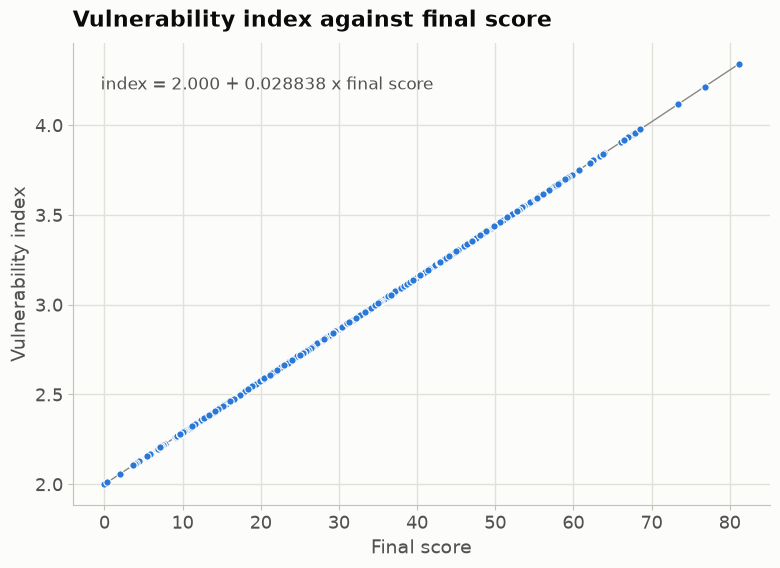

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
ends = pd.DataFrame({"FinalScore": [0.0, final.max()]})
ax.plot(ends["FinalScore"], affine.predict(ends), color=MUTED, linewidth=1, zorder=1)
ax.scatter(final, index, s=28, color=BLUE, edgecolor=SURFACE, linewidth=0.8, zorder=2)
ax.annotate(
    f"index = {affine.intercept_:.3f} + {affine.coef_[0]:.6f} x final score",
    xy=(0.04, 0.9),
    xycoords="axes fraction",
    fontsize=12,
    color=INK_SECONDARY,
)
ax.set(
    title="Vulnerability index against final score",
    xlabel="Final score",
    ylabel="Vulnerability index",
)
ax.grid(axis="x")
save_figure(fig, "vulnerability_index_vs_final_score")

Category bands: the score range of each recorded category, the interval in which
each cutpoint must lie, and the households whose category the cutpoints do not
reproduce.

In [16]:
category_labels = list(VALUE_LABELS["Vulnerability_Category"].values())
recorded = data["Vulnerability_Category"]
codes = recorded.cat.codes.to_numpy()
banded = scorecard.category(index).map(VALUE_LABELS["Vulnerability_Category"])
matches = banded.to_numpy() == recorded.astype(str).to_numpy()
bands = (
    pd.DataFrame({"category": recorded, "final": final, "index": index})
    .groupby("category", observed=True)
    .agg(
        n=("final", "size"),
        final_min=("final", "min"),
        final_median=("final", "median"),
        final_max=("final", "max"),
        index_min=("index", "min"),
        index_max=("index", "max"),
    )
    .reset_index()
)
save_table(bands, "category_bands")

,category,n,final_min,final_median,final_max,index_min,index_max
0,Low,775,0.000000,13.709194,24.254152,2.000000,2.699438
1,Moderate,394,24.597091,27.520617,36.964426,2.709328,3.065975
2,High,612,31.269382,39.076517,51.689152,2.901742,3.490605
3,Severe,119,52.205472,57.011979,81.126802,3.505494,4.339524


In [17]:
def threshold_mismatches(lower: int, threshold: float) -> int:
    """Rows of categories lower and lower + 1 that fall on the wrong side of threshold."""
    above = (codes == lower) & (final >= threshold)
    below = (codes == lower + 1) & (final < threshold)
    return int((above | below).sum())


cutpoint_rows = []
for lower, cutpoint in enumerate(scorecard.CATEGORY_CUTPOINTS):
    upper_start = final[codes == lower + 1].min()
    lower_end = final[(codes == lower) & (final < upper_start)].max()
    thresholds = np.unique(final[(codes == lower) | (codes == lower + 1)])
    cutpoint_rows.append(
        {
            "boundary": f"{category_labels[lower]} | {category_labels[lower + 1]}",
            "final_score_interval_from": lower_end,
            "final_score_interval_to": upper_start,
            "index_interval_from": index[final == lower_end].iloc[0],
            "index_interval_to": index[final == upper_start].iloc[0],
            "index_cutpoint": cutpoint,
            "final_score_at_index_cutpoint": scorecard.final_from_index(cutpoint),
            "lower_category_rows_above_interval": int(
                ((codes == lower) & (final > upper_start)).sum()
            ),
            "fewest_mismatches_any_threshold": min(
                threshold_mismatches(lower, t) for t in thresholds
            ),
        }
    )
cutpoints = save_table(pd.DataFrame(cutpoint_rows), "category_cutpoints")
cutpoints

,boundary,final_score_interval_from,final_score_interval_to,index_interval_from,index_interval_to,index_cutpoint,final_score_at_index_cutpoint,lower_category_rows_above_interval,fewest_mismatches_any_threshold
0,Low | Moderate,24.254152,24.597091,2.699438,2.709328,2.7,24.273645,0,0
1,Moderate | High,31.090689,31.269382,2.896589,2.901742,2.9,31.208972,10,10
2,High | Severe,51.689152,52.205472,3.490605,3.505494,3.5,52.014953,0,0


In [18]:
combination = raw.groupby(FACTORS).ngroup()
mismatches = pd.DataFrame(
    {
        "final_score": final,
        "vulnerability_index": index,
        "recorded_category": recorded,
        "category_from_cutpoints": banded,
        "households_with_same_factors": combination.map(combination.value_counts()),
        "of_which_recorded_high": (recorded == "High")
        .groupby(combination)
        .transform("sum"),
    }
)[~matches].sort_values("final_score")
category_agreement = pd.DataFrame(
    [
        ("Households", len(raw)),
        ("Category reproduced by the index cutpoints", int(matches.sum())),
        ("Category not reproduced", int((~matches).sum())),
        (
            "Not reproduced and sharing all factor scores with a household recorded High",
            int((mismatches["of_which_recorded_high"] > 0).sum()),
        ),
    ],
    columns=["statistic", "value"],
)
save_table(category_agreement, "category_agreement")
save_table(mismatches, "category_mismatches")

,final_score,vulnerability_index,recorded_category,category_from_cutpoints,households_with_same_factors,of_which_recorded_high
545,31.332255,2.903555,Moderate,High,4,3
1699,32.735852,2.944032,Moderate,High,5,4
567,34.610893,2.998104,Moderate,High,22,21
107,34.952459,3.007954,Moderate,High,7,5
551,34.952459,3.007954,Moderate,High,7,5
47,35.193856,3.014916,Moderate,High,2,0
1842,35.193856,3.014916,Moderate,High,2,0
604,36.121621,3.041671,Moderate,High,3,2
930,36.964426,3.065975,Moderate,High,2,0
1131,36.964426,3.065975,Moderate,High,2,0


The sample cannot tell the index cutpoints apart from round final-score cutpoints
in the same intervals. Enumerating every possible combination of factor levels
shows how many scores that choice could affect.

In [19]:
grid = pd.DataFrame(
    list(itertools.product(*scorecard.FACTOR_LEVELS.values())), columns=FACTORS
)
grid_final = scorecard.final_score(grid)
grid_index_rule = np.digitize(
    scorecard.vulnerability_index(grid), scorecard.CATEGORY_CUTPOINTS
)
grid_final_rule = np.digitize(grid_final, ALTERNATIVE_FINAL_CUTPOINTS)
sample_rules_differ = np.digitize(index, scorecard.CATEGORY_CUTPOINTS) != np.digitize(
    final, ALTERNATIVE_FINAL_CUTPOINTS
)
uncertainty_rows = [
    (
        f"Possible combinations scoring inside the {row.boundary} interval",
        int(
            (
                (grid_final > row.final_score_interval_from)
                & (grid_final < row.final_score_interval_to)
            ).sum()
        ),
    )
    for row in cutpoints.itertuples()
]
uncertainty_rows += [
    ("Possible combinations of the 8 factor levels", len(grid)),
    (
        "Possible combinations categorised differently by index and final-score cutpoints",
        int((grid_index_rule != grid_final_rule).sum()),
    ),
    (
        "Sample households categorised differently by the two sets of cutpoints",
        int(sample_rules_differ.sum()),
    ),
    ("Highest possible final score", grid_final.max()),
]
cutpoint_uncertainty = pd.DataFrame(uncertainty_rows, columns=["statistic", "value"])
save_table(cutpoint_uncertainty, "category_cutpoint_uncertainty")

,statistic,value
0,Possible combinations scoring inside the Low |...,66.0
1,Possible combinations scoring inside the Moder...,48.0
2,Possible combinations scoring inside the High ...,122.0
3,Possible combinations of the 8 factor levels,13824.0
4,Possible combinations categorised differently ...,52.0
5,Sample households categorised differently by t...,0.0
6,Highest possible final score,100.0


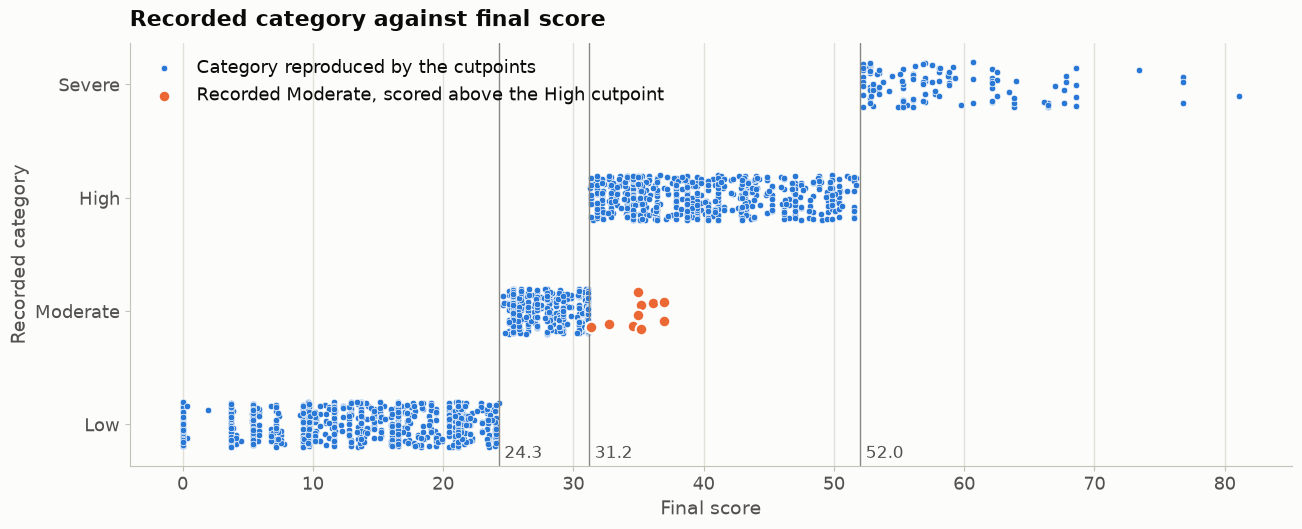

In [20]:
fig, ax = plt.subplots(figsize=(15, 5.5))
jitter = rng.uniform(-0.2, 0.2, len(raw))
ax.scatter(
    final[matches],
    codes[matches] + jitter[matches],
    s=22,
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=0.5,
    label="Category reproduced by the cutpoints",
)
ax.scatter(
    final[~matches],
    codes[~matches] + jitter[~matches],
    s=70,
    color=ORANGE,
    edgecolor=SURFACE,
    linewidth=1.5,
    zorder=3,
    label="Recorded Moderate, scored above the High cutpoint",
)
for cutpoint in scorecard.CATEGORY_CUTPOINTS:
    position = scorecard.final_from_index(cutpoint)
    ax.axvline(position, color=MUTED, linewidth=1, zorder=1)
    ax.annotate(
        f"{position:.1f}",
        xy=(position, 0.0),
        xycoords=("data", "axes fraction"),
        xytext=(4, 6),
        textcoords="offset points",
        fontsize=12,
        color=INK_SECONDARY,
    )
ax.set_yticks(range(len(category_labels)), category_labels)
ax.set(
    title="Recorded category against final score",
    xlabel="Final score",
    ylabel="Recorded category",
)
ax.grid(axis="x")
ax.grid(visible=False, axis="y")
ax.legend(loc="upper left")
save_figure(fig, "category_bands")

## 3. Score structure

Candidate forms for the mapping from the factor scores to the two block scores and
the final score, from a linear fit to the recovered geometric-mean formula. Errors
are in-sample: a form that cannot fit the data it was estimated on cannot be the
rule that generated it.

In [21]:
def fit_summary(target, form, observed, predicted, parameters, note=""):
    """R squared, mean and largest absolute error of one candidate form."""
    observed = np.asarray(observed, dtype=float)
    error = observed - np.asarray(predicted, dtype=float)
    return {
        "target": target,
        "form": form,
        "fitted_parameters": parameters,
        "r2": 1 - (error**2).sum() / ((observed - observed.mean()) ** 2).sum(),
        "mae": np.abs(error).mean(),
        "max_abs_error": np.abs(error).max(),
        "note": note,
    }


def product_form(x, scale, *exponents):
    """scale x (product of factor powers - 1), which is 0 when every factor is 1.0."""
    return scale * (np.prod(x ** np.reshape(exponents, (-1, 1)), axis=0) - 1)


targets = {
    "Demographics score": (
        DEMOGRAPHIC_FACTORS,
        demographics,
        scorecard.block_score(raw[DEMOGRAPHIC_FACTORS]),
    ),
    "Needs and coping score": (
        NEEDS_FACTORS,
        needs,
        scorecard.block_score(raw[NEEDS_FACTORS]),
    ),
    "Final score": (FACTORS, final, scorecard.final_score(raw)),
}
candidate_rows = []
for target, (columns, observed, formula) in targets.items():
    factors = raw[columns]
    logs = np.log(factors)
    positive = observed > 0
    linear = LinearRegression().fit(factors, observed)
    in_logs = LinearRegression().fit(logs, observed)
    log_log = LinearRegression().fit(logs[positive], np.log(observed[positive]))
    start = [30.0] + [1 / len(columns)] * len(columns)
    params, _ = curve_fit(
        product_form, factors.to_numpy().T, observed.to_numpy(), p0=start, maxfev=50_000
    )
    lookup_key = raw.groupby(columns).ngroup()
    possible = int(np.prod([len(scorecard.FACTOR_LEVELS[c]) for c in columns]))
    exponents = ", ".join(f"{e:.3f}" for e in params[1:])
    candidate_rows += [
        fit_summary(
            target, "Linear", observed, linear.predict(factors), len(columns) + 1
        ),
        fit_summary(
            target,
            "Linear in log factors",
            observed,
            in_logs.predict(logs),
            len(columns) + 1,
        ),
        fit_summary(
            target,
            "Log-linear",
            observed[positive],
            np.exp(log_log.predict(logs[positive])),
            len(columns) + 1,
            f"log score on log factors; only the {positive.sum():,} rows with a score above 0",
        ),
        fit_summary(
            target,
            "Multiplicative",
            observed,
            product_form(factors.to_numpy().T, *params),
            len(params),
            f"scale x (product of factor powers - 1); scale {params[0]:.3f}, exponents {exponents}",
        ),
        fit_summary(
            target,
            "Lookup table",
            observed,
            observed.groupby(lookup_key).transform("mean"),
            lookup_key.nunique(),
            f"in-sample only; covers {lookup_key.nunique()} of {possible:,} possible combinations",
        ),
        fit_summary(
            target,
            "Recovered formula",
            observed,
            formula,
            0,
            "rescaled geometric mean of the factor scores; no fitted parameters",
        ),
    ]
candidates = save_table(pd.DataFrame(candidate_rows), "score_structure_candidates")
candidates

,target,form,fitted_parameters,r2,mae,max_abs_error,note
0,Demographics score,Linear,5,0.991125,5.654372e-01,5.450278e+00,
1,Demographics score,Linear in log factors,5,0.988138,7.650165e-01,6.937952e+00,
2,Demographics score,Log-linear,5,0.901882,1.286529e+00,2.133279e+01,"log score on log factors; only the 1,244 rows ..."
3,Demographics score,Multiplicative,5,1.000000,1.016386e-09,6.122974e-09,scale x (product of factor powers - 1); scale ...
4,Demographics score,Lookup table,55,1.000000,1.227089e-16,1.776357e-15,in-sample only; covers 55 of 144 possible comb...
5,Demographics score,Recovered formula,0,1.000000,1.031045e-09,4.836316e-09,rescaled geometric mean of the factor scores; ...
6,Needs and coping score,Linear,5,0.993279,6.204601e-01,5.482712e+00,
7,Needs and coping score,Linear in log factors,5,0.991617,7.437316e-01,4.692460e+00,
8,Needs and coping score,Log-linear,5,0.914944,2.128898e+00,1.297313e+01,"log score on log factors; only the 1,808 rows ..."
9,Needs and coping score,Multiplicative,5,1.000000,2.174583e-09,8.473684e-09,scale x (product of factor powers - 1); scale ...


In [22]:
top_d = scorecard.top_geometric_mean(DEMOGRAPHIC_FACTORS)
top_n = scorecard.top_geometric_mean(NEEDS_FACTORS)
constants = [
    ("Geometric mean of the demographic factors at their highest levels (G_D)", top_d),
    (
        "Geometric mean of the needs and coping factors at their highest levels (G_N)",
        top_n,
    ),
    (
        "Demographics score scale, 50 / (G_D - 1)",
        scorecard.BLOCK_MAX_SCORE / (top_d - 1),
    ),
    (
        "Needs and coping score scale, 50 / (G_N - 1)",
        scorecard.BLOCK_MAX_SCORE / (top_n - 1),
    ),
    (
        "Final score scale, 100 / (G_D + G_N - 2)",
        scorecard.FINAL_MAX_SCORE / (top_d + top_n - 2),
    ),
    ("Weight of the demographics score in the final score", weight_d),
    ("Weight of the needs and coping score in the final score", weight_n),
]
for row in cutpoints.itertuples():
    constants += [
        (f"Vulnerability index cutpoint, {row.boundary}", row.index_cutpoint),
        (
            f"Final score at that cutpoint, {row.boundary}",
            row.final_score_at_index_cutpoint,
        ),
    ]
save_table(
    pd.DataFrame(constants, columns=["constant", "value"]), "scorecard_constants"
)

,constant,value
0,Geometric mean of the demographic factors at t...,2.488294
1,Geometric mean of the needs and coping factors...,2.395492
2,"Demographics score scale, 50 / (G_D - 1)",33.595510
3,"Needs and coping score scale, 50 / (G_N - 1)",35.829658
4,"Final score scale, 100 / (G_D + G_N - 2)",34.676636
5,Weight of the demographics score in the final ...,1.032181
6,Weight of the needs and coping score in the fi...,0.967819
7,"Vulnerability index cutpoint, Low | Moderate",2.700000
8,"Final score at that cutpoint, Low | Moderate",24.273645
9,"Vulnerability index cutpoint, Moderate | High",2.900000


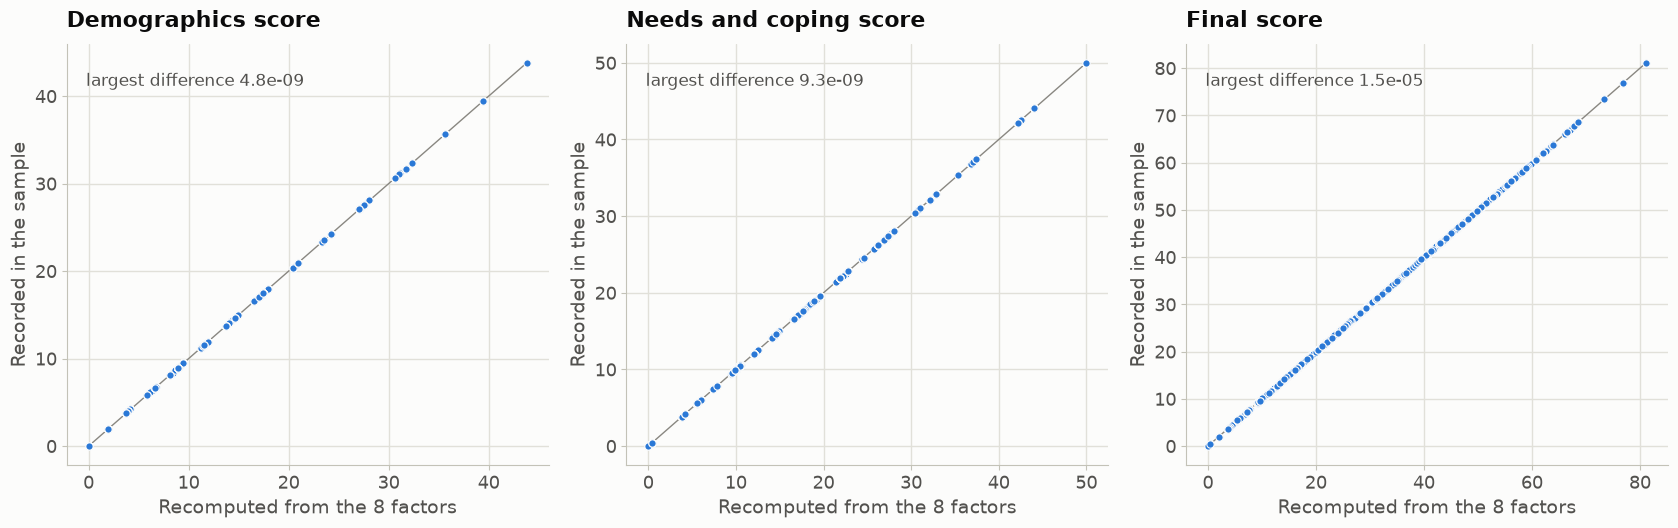

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (target, (_, observed, formula)) in zip(axes, targets.items()):
    top = max(observed.max(), formula.max())
    ax.plot([0, top], [0, top], color=MUTED, linewidth=1, zorder=1)
    ax.scatter(
        formula, observed, s=28, color=BLUE, edgecolor=SURFACE, linewidth=0.8, zorder=2
    )
    ax.annotate(
        f"largest difference {np.abs(observed - formula).max():.1e}",
        xy=(0.04, 0.9),
        xycoords="axes fraction",
        fontsize=12,
        color=INK_SECONDARY,
    )
    ax.set(
        title=target,
        xlabel="Recomputed from the 8 factors",
        ylabel="Recorded in the sample",
    )
    ax.grid(axis="x")
fig.tight_layout()
save_figure(fig, "score_formula_check")

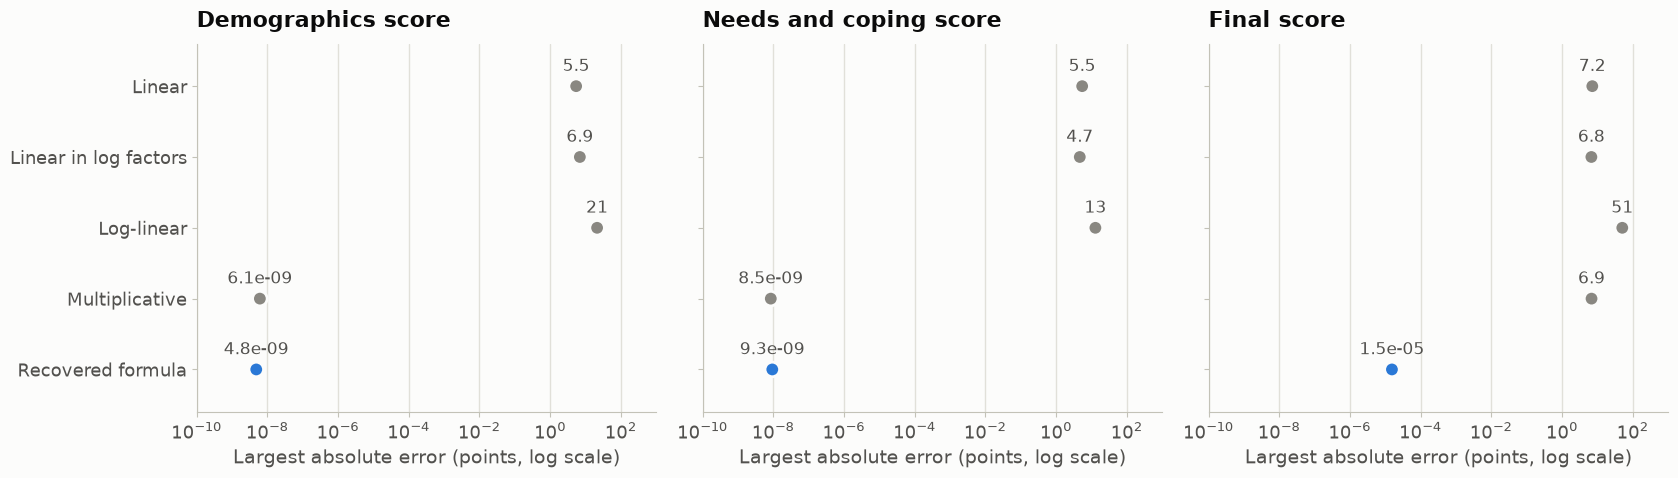

In [24]:
shown_forms = [
    "Linear",
    "Linear in log factors",
    "Log-linear",
    "Multiplicative",
    "Recovered formula",
]
positions = np.arange(len(shown_forms))
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, (target, rows) in zip(axes, candidates.groupby("target", sort=False)):
    errors = rows.set_index("form").loc[shown_forms, "max_abs_error"].to_numpy()
    colors = [BLUE if form == "Recovered formula" else MUTED for form in shown_forms]
    ax.scatter(
        errors, positions, s=110, color=colors, edgecolor=SURFACE, linewidth=2, zorder=2
    )
    for y, value in zip(positions, errors):
        ax.annotate(
            f"{value:.2g}",
            (value, y),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            fontsize=12,
            color=INK_SECONDARY,
        )
    ax.set_xscale("log")
    ax.set_xlim(1e-10, 1e3)
    ax.set(title=target, xlabel="Largest absolute error (points, log scale)")
    ax.grid(axis="x")
    ax.grid(visible=False, axis="y")
axes[0].set_yticks(positions, shown_forms)
axes[0].set_ylim(len(shown_forms) - 0.4, -0.6)
fig.tight_layout()
save_figure(fig, "candidate_forms_error")

What each factor contributes on its own, and how much more the factors give when
raised together.

In [25]:
baseline = pd.DataFrame({column: [1.0] for column in FACTORS})
effect_rows = []
for column in FACTORS:
    in_demographics = column in DEMOGRAPHIC_FACTORS
    block_columns = DEMOGRAPHIC_FACTORS if in_demographics else NEEDS_FACTORS
    for level in scorecard.FACTOR_LEVELS[column][1:]:
        profile = baseline.copy()
        profile[column] = level
        effect_rows.append(
            {
                "block": "Demographics" if in_demographics else "Needs and coping",
                "factor": ENGLISH_NAMES[column],
                "level": level,
                "households_at_level": int((raw[column] == level).sum()),
                "block_score_alone": scorecard.block_score(profile[block_columns]).iloc[
                    0
                ],
                "final_score_alone": scorecard.final_score(profile).iloc[0],
            }
        )
single_effects = save_table(pd.DataFrame(effect_rows), "single_factor_effects")
single_effects

,block,factor,level,households_at_level,block_score_alone,final_score_alone
0,Demographics,Head of household,1.599561,35,4.186185,4.320899
1,Demographics,Head of household,2.070142,282,6.702282,6.917966
2,Demographics,Head of household,2.700708,322,9.472088,9.776906
3,Demographics,Language barrier,1.525552,175,3.741370,3.861770
4,Demographics,Language barrier,2.051105,196,6.609317,6.822010
5,Demographics,Specific needs,1.249197,86,1.921713,1.983555
6,Demographics,Specific needs,2.578385,490,8.975915,9.264766
7,Demographics,Specific needs,3.251728,191,11.518330,11.888997
8,Demographics,Documentation,1.564136,59,3.975240,4.103166
9,Demographics,Documentation,2.128272,3,6.982245,7.206939


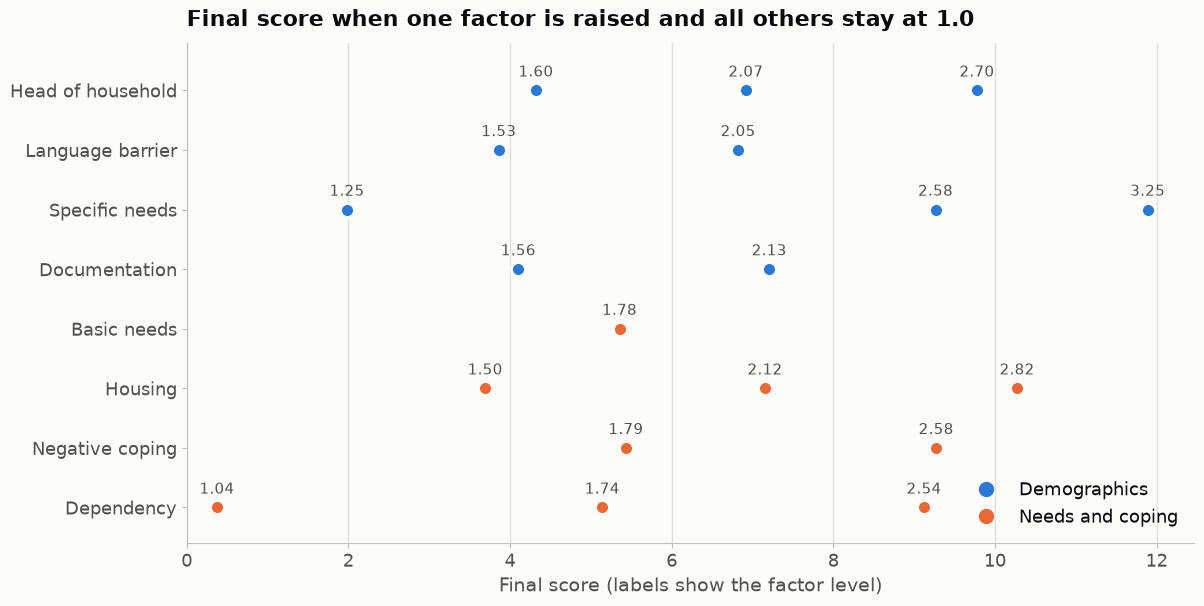

In [26]:
factor_names = [ENGLISH_NAMES[column] for column in FACTORS]
fig, ax = plt.subplots(figsize=(13, 6.5))
for row, name in enumerate(factor_names):
    subset = single_effects[single_effects["factor"] == name]
    color = BLUE if subset["block"].iloc[0] == "Demographics" else ORANGE
    ax.scatter(
        subset["final_score_alone"],
        [row] * len(subset),
        s=100,
        color=color,
        edgecolor=SURFACE,
        linewidth=2,
        zorder=3,
    )
    for effect in subset.itertuples():
        ax.annotate(
            f"{effect.level:.2f}",
            (effect.final_score_alone, row),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=11,
            color=INK_SECONDARY,
        )
ax.set_yticks(range(len(factor_names)), factor_names)
ax.set_ylim(len(factor_names) - 0.4, -0.8)
ax.set_xlim(left=0)
ax.set(
    title="Final score when one factor is raised and all others stay at 1.0",
    xlabel="Final score (labels show the factor level)",
)
ax.grid(axis="x")
ax.grid(visible=False, axis="y")
ax.legend(
    handles=[
        Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=10,
            color=BLUE,
            label="Demographics",
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=10,
            color=ORANGE,
            label="Needs and coping",
        ),
    ],
    loc="lower right",
)
save_figure(fig, "single_factor_effects")

In [27]:
single_sum = pd.Series(0.0, index=raw.index)
for column in FACTORS:
    profile = pd.DataFrame(1.0, index=raw.index, columns=FACTORS)
    profile[column] = raw[column]
    single_sum += scorecard.final_score(profile)
interaction = final - single_sum
raised_together = ((raw[DEMOGRAPHIC_FACTORS] > 1).sum(axis=1) > 1) | (
    (raw[NEEDS_FACTORS] > 1).sum(axis=1) > 1
)
interaction_summary = pd.DataFrame(
    [
        (
            "Mean of final score minus the sum of single-factor effects",
            interaction.mean(),
        ),
        ("Median of the difference", interaction.median()),
        ("Largest difference", interaction.max()),
        ("Smallest difference", interaction.min()),
        (
            "Share of households with a difference above 1 point",
            (interaction > 1).mean(),
        ),
        (
            "Share of households with two or more raised factors in one block",
            raised_together.mean(),
        ),
        (
            "Largest absolute difference where no block has two raised factors",
            interaction[~raised_together].abs().max(),
        ),
    ],
    columns=["statistic", "value"],
)
save_table(interaction_summary, "factor_interaction")

,statistic,value
0,Mean of final score minus the sum of single-fa...,3.904150
1,Median of the difference,3.466685
2,Largest difference,21.240360
3,Smallest difference,-0.000004
4,Share of households with a difference above 1 ...,0.751053
5,Share of households with two or more raised fa...,0.861053
6,Largest absolute difference where no block has...,0.000004


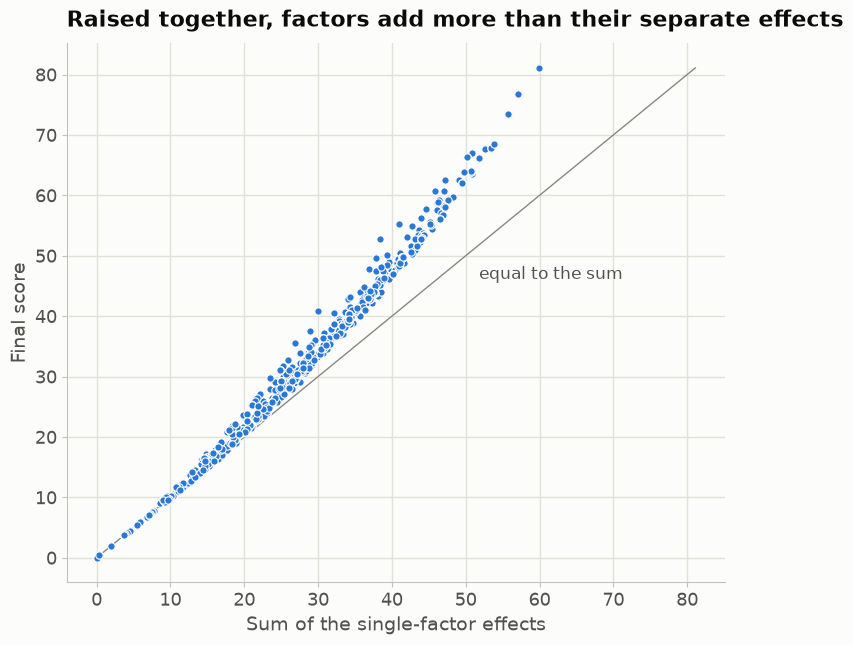

In [28]:
fig, ax = plt.subplots(figsize=(8.5, 7))
top = final.max()
ax.plot([0, top], [0, top], color=MUTED, linewidth=1, zorder=1)
ax.scatter(
    single_sum, final, s=28, color=BLUE, edgecolor=SURFACE, linewidth=0.8, zorder=2
)
ax.annotate(
    "equal to the sum",
    xy=(0.62 * top, 0.62 * top),
    xytext=(8, -18),
    textcoords="offset points",
    fontsize=12,
    color=INK_SECONDARY,
)
ax.set(
    title="Raised together, factors add more than their separate effects",
    xlabel="Sum of the single-factor effects",
    ylabel="Final score",
)
ax.grid(axis="x")
save_figure(fig, "final_score_vs_single_factor_sum")

The formula needs nothing beyond the eight factors. The household attributes are
compared with the factors to see whether they carry the same information.

In [29]:
attribute_factor = pd.DataFrame(
    [
        [cramers_v(data[attribute], raw[factor].round(2)) for factor in FACTORS]
        for attribute in HOUSEHOLD_ATTRIBUTES
    ],
    index=[ENGLISH_NAMES[attribute] for attribute in HOUSEHOLD_ATTRIBUTES],
    columns=factor_names,
)
save_table(
    attribute_factor.reset_index(names="household_attribute"),
    "attribute_factor_association",
)

,household_attribute,Head of household,Language barrier,Specific needs,Documentation,Basic needs,Housing,Negative coping,Dependency
0,Household size,0.075247,0.024987,0.076107,0.000000,0.142831,0.096886,0.144858,0.068244
1,Dependency category,0.133225,0.088485,0.133404,0.013474,0.200272,0.140847,0.170530,0.124442
2,Sex of household head,0.115943,0.053698,0.112666,0.000000,0.159024,0.133419,0.146154,0.100334
3,Sole carer,0.126052,0.071304,0.115324,0.000000,0.158423,0.131611,0.156144,0.118323
4,Speaks Spanish,0.000000,0.000000,0.036218,0.000000,0.052756,0.064685,0.061071,0.072993
5,Adult illiteracy,0.109843,0.069848,0.145259,0.017465,0.081683,0.136136,0.121268,0.123435


In [30]:
spanish_language = pd.crosstab(
    data["HablaEspanol"],
    raw["Demographics.Language"].map(lambda level: f"Language barrier {level:.2f}"),
)
spanish_language = spanish_language.reset_index(names="speaks_spanish")
save_table(spanish_language, "speaks_spanish_by_language_barrier")

Demographics.Language,speaks_spanish,Language barrier 1.00,Language barrier 1.53,Language barrier 2.05
0,One or more adults,1304,151,167
1,No adult,225,24,29


## 4. Univariate distributions

In [31]:
numeric_columns = [
    "FinalScore",
    "Demographics_Score",
    "NeedsandCoping_Score",
    "Vulnerability_Score",
    "NumIntegrantes",
]
univariate_numeric = raw[numeric_columns].describe().T
univariate_numeric["share_at_minimum"] = [
    raw[column].eq(raw[column].min()).mean() for column in numeric_columns
]
univariate_numeric = univariate_numeric.rename(index=ENGLISH_NAMES).reset_index(
    names="variable"
)
save_table(univariate_numeric, "univariate_numeric")

,variable,count,mean,std,min,25%,50%,75%,max,share_at_minimum
0,Final score,1900.0,27.742527,14.900947,0.0,16.557934,27.087580,37.912700,81.126802,0.026316
1,Demographics score,1900.0,8.072326,8.506504,0.0,0.000000,6.702282,11.518330,43.805174,0.345263
2,Needs and coping score,1900.0,20.055843,10.954609,0.0,12.014136,21.885122,27.408799,50.000000,0.048421
3,Vulnerability index,1900.0,2.800035,0.429711,2.0,2.477496,2.781148,3.093321,4.339524,0.026316
4,Household size,1900.0,2.151053,1.427491,1.0,1.000000,2.000000,3.000000,11.000000,0.486842


In [32]:
categorical_columns = (
    FACTORS
    + HOUSEHOLD_ATTRIBUTES[1:]
    + ADMIN_FLAGS
    + INTERVIEW_RECORD
    + ["Vulnerability_Category", "Elegibilidad", "EligibilityTarget"]
)
frames = []
for column in categorical_columns:
    if column in FACTORS:
        counts = raw[column].value_counts().sort_index()
        levels = [f"{level:.2f}" for level in counts.index]
    else:
        counts = data[column].value_counts(sort=False)
        counts = counts.sort_index() if column == "month" else counts
        levels = counts.index.astype(str)
    frames.append(
        pd.DataFrame(
            {
                "variable": ENGLISH_NAMES[column],
                "level": levels,
                "n": counts.to_numpy(),
                "share": counts.to_numpy() / len(raw),
            }
        )
    )
univariate_categorical = save_table(
    pd.concat(frames, ignore_index=True), "univariate_categorical"
)

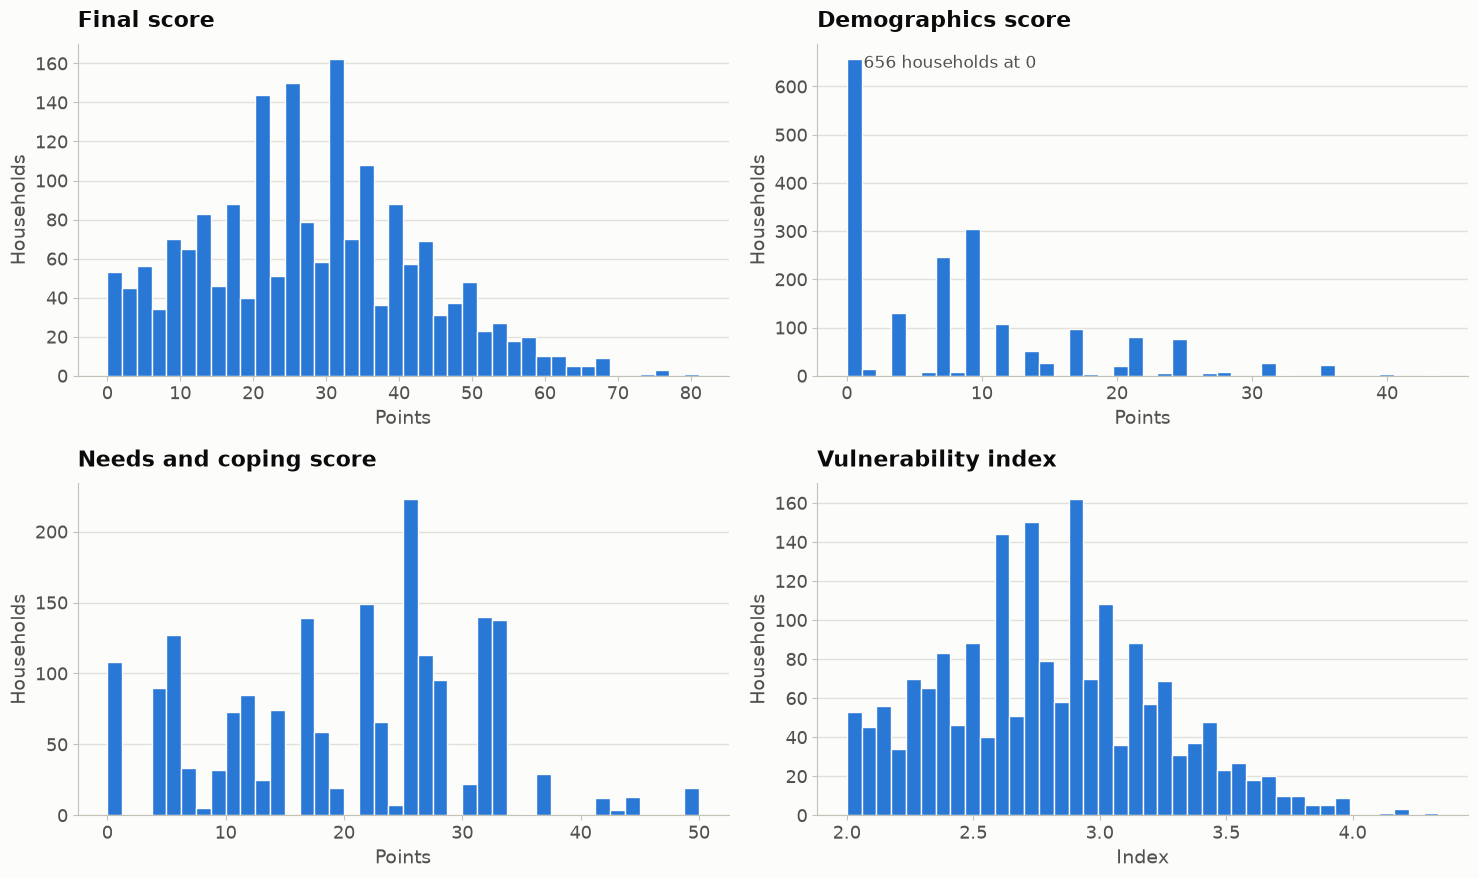

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, column in zip(axes.flat, numeric_columns[:4]):
    ax.hist(raw[column], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=1)
    ax.set(
        title=ENGLISH_NAMES[column],
        xlabel="Index" if column == "Vulnerability_Score" else "Points",
        ylabel="Households",
    )
zero_demographics = int(demographics.eq(0).sum())
axes[0, 1].annotate(
    f"{zero_demographics:,} households at 0",
    xy=(0, zero_demographics),
    xytext=(12, -6),
    textcoords="offset points",
    fontsize=12,
    color=INK_SECONDARY,
)
fig.tight_layout()
save_figure(fig, "distribution_scores")

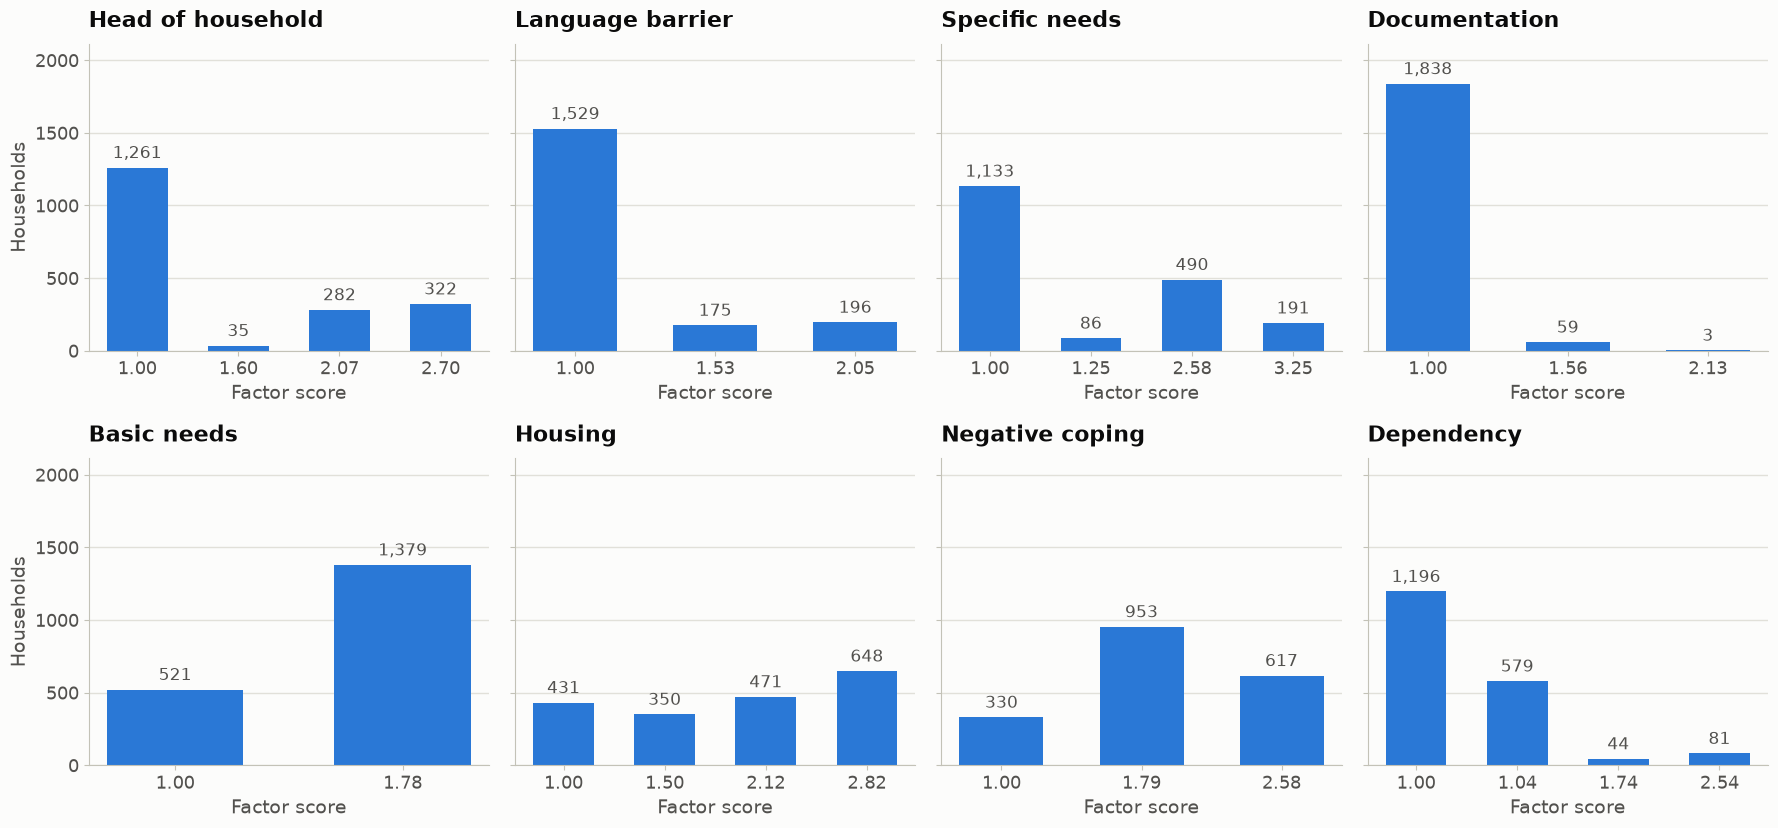

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8.5), sharey=True)
for ax, column in zip(axes.flat, FACTORS):
    counts = raw[column].value_counts().sort_index()
    counts.index = [f"{level:.2f}" for level in counts.index]
    plot_counts(ax, counts)
    ax.set(title=ENGLISH_NAMES[column], xlabel="Factor score")
for ax in axes[:, 0]:
    ax.set_ylabel("Households")
fig.tight_layout()
save_figure(fig, "distribution_factor_levels")

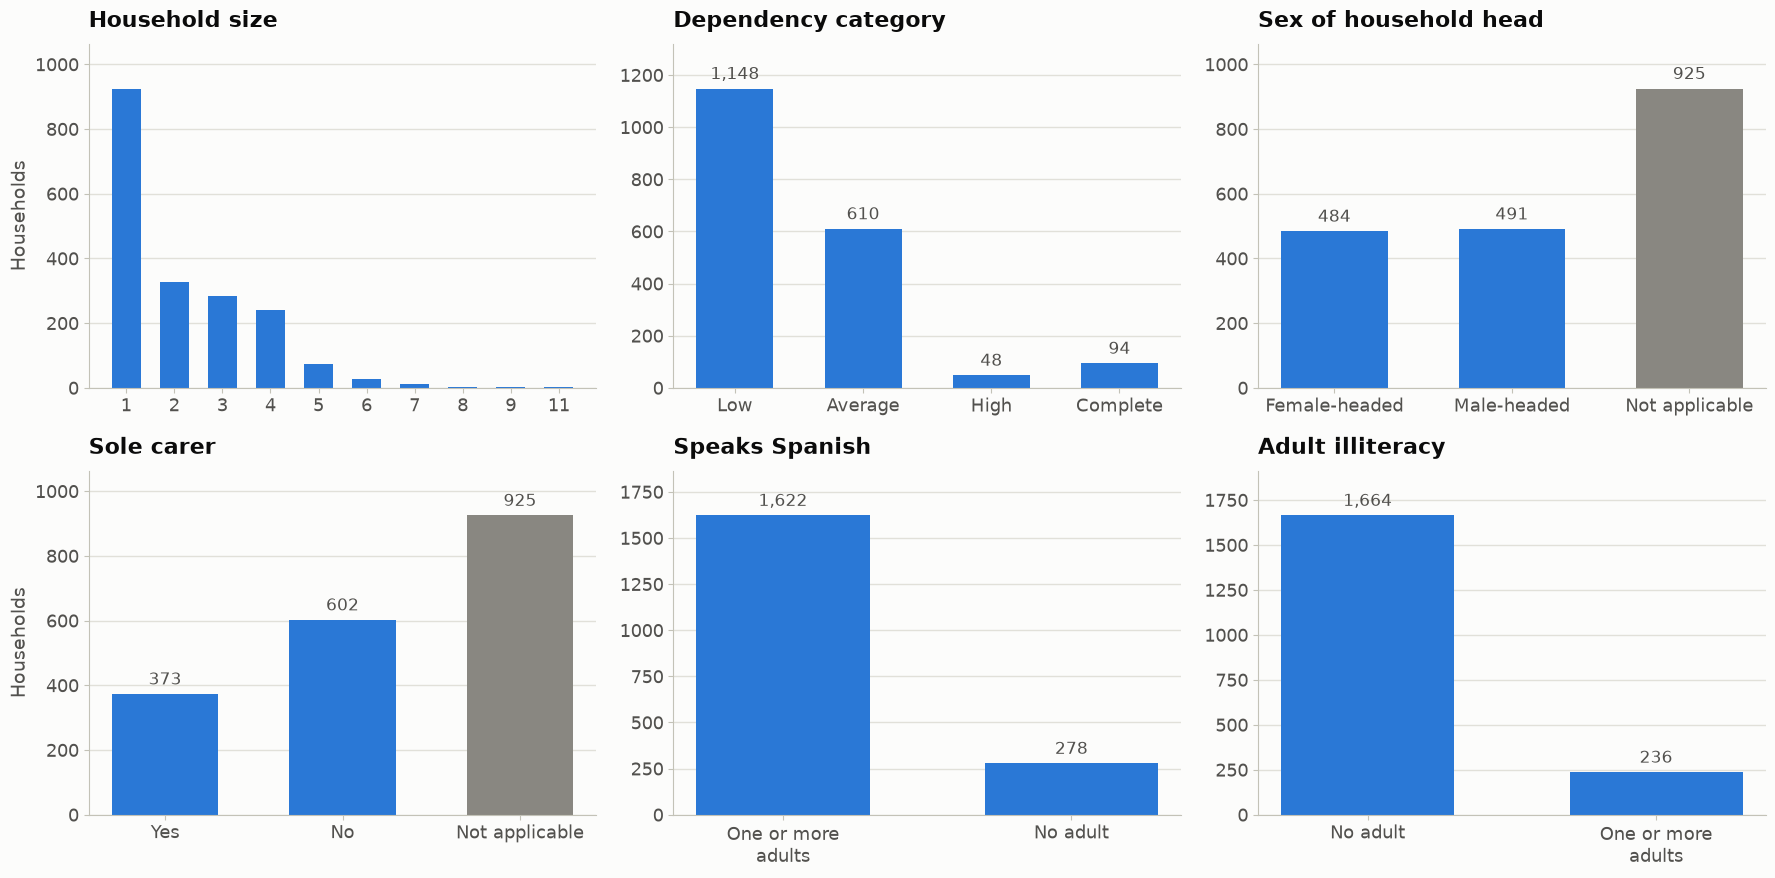

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, column in zip(axes.flat, HOUSEHOLD_ATTRIBUTES):
    counts = data[column].value_counts(sort=False)
    if column == "NumIntegrantes":
        counts = counts.sort_index()
    plot_counts(ax, counts, label_values=column != "NumIntegrantes")
    ax.set(title=ENGLISH_NAMES[column])
for ax in axes[:, 0]:
    ax.set_ylabel("Households")
fig.tight_layout()
save_figure(fig, "distribution_household_attributes")

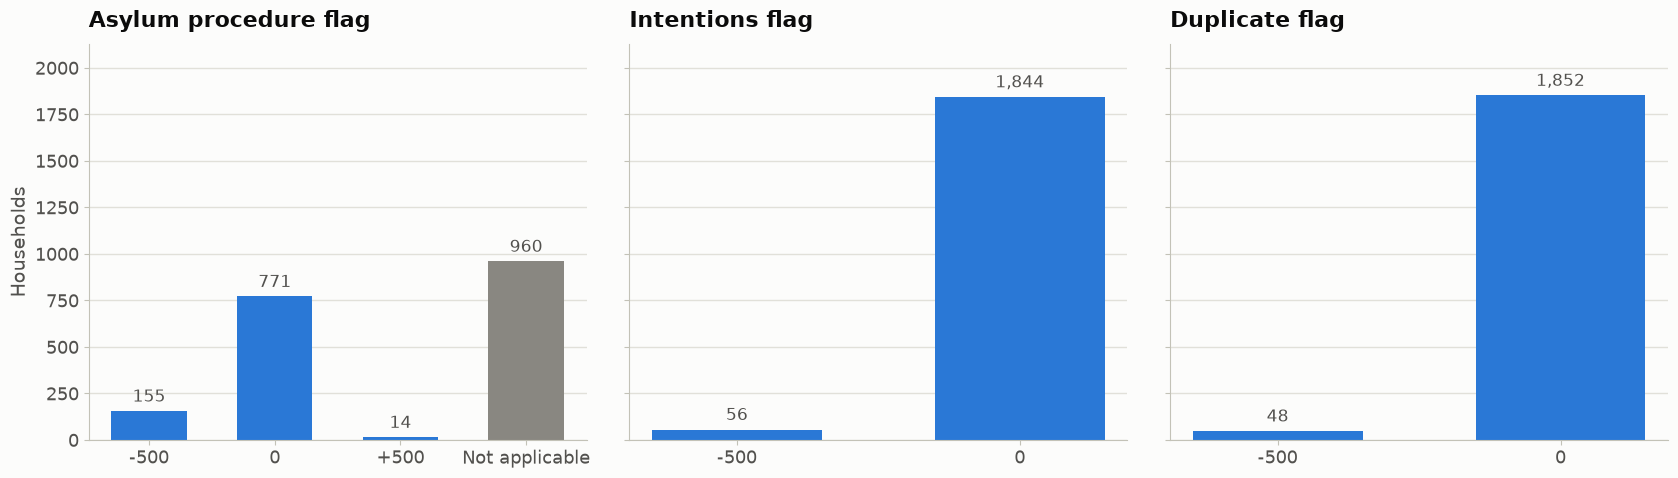

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, column in zip(axes, ADMIN_FLAGS):
    plot_counts(ax, data[column].value_counts(sort=False))
    ax.set(title=ENGLISH_NAMES[column])
axes[0].set_ylabel("Households")
fig.tight_layout()
save_figure(fig, "distribution_admin_flags")

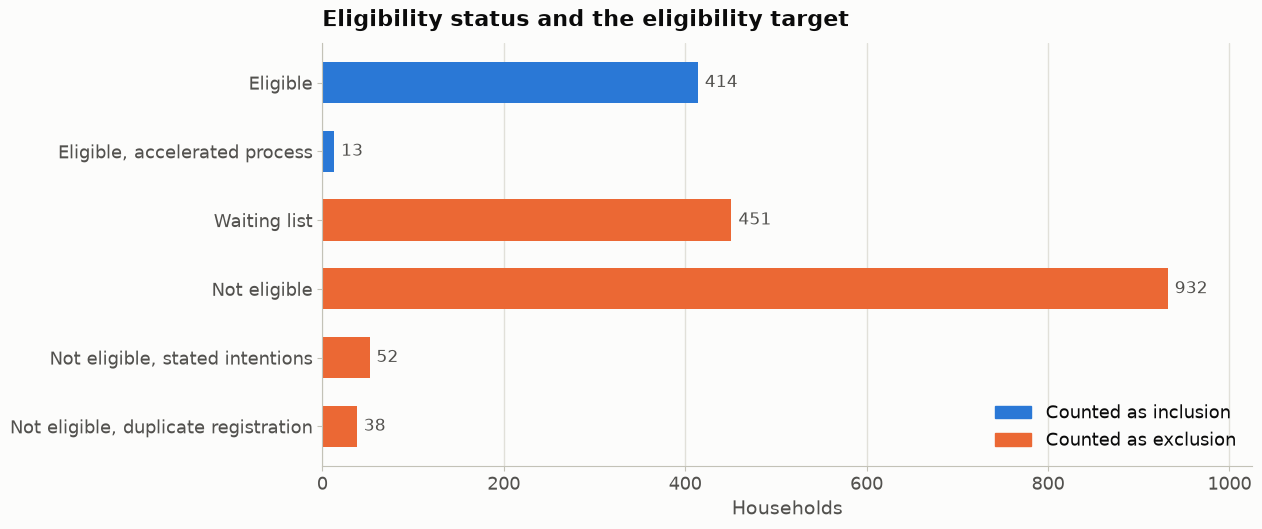

In [37]:
status_counts = data["Elegibilidad"].value_counts(sort=False)
inclusion_labels = [
    VALUE_LABELS["Elegibilidad"][status] for status in INCLUSION_STATUSES
]
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.barh(
    range(len(status_counts)),
    status_counts.to_numpy(),
    height=0.6,
    color=[
        BLUE if label in inclusion_labels else ORANGE for label in status_counts.index
    ],
)
for y, value in enumerate(status_counts.to_numpy()):
    ax.annotate(
        f"{value:,}",
        (value, y),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=12,
        color=INK_SECONDARY,
    )
ax.set_yticks(range(len(status_counts)), status_counts.index)
ax.invert_yaxis()
ax.margins(x=0.1)
ax.set(title="Eligibility status and the eligibility target", xlabel="Households")
ax.grid(axis="x")
ax.grid(visible=False, axis="y")
ax.legend(
    handles=[
        Patch(color=BLUE, label="Counted as inclusion"),
        Patch(color=ORANGE, label="Counted as exclusion"),
    ],
    loc="lower right",
)
save_figure(fig, "distribution_eligibility_status")

## 5. Bivariate associations

Each candidate input against the final score: Spearman's rho for numeric inputs
and the correlation ratio eta for categorical ones, with a Kruskal-Wallis test.

In [38]:
inputs = FACTORS + HOUSEHOLD_ATTRIBUTES + ADMIN_FLAGS + INTERVIEW_RECORD
numeric_inputs = FACTORS + ["NumIntegrantes"]
association_rows = []
for column in inputs:
    if column in numeric_inputs:
        result = stats.spearmanr(raw[column], final)
        measure, value, p_value = "Spearman rho", result.statistic, result.pvalue
    else:
        groups = data[column]
        samples = [values for _, values in final.groupby(groups, observed=True)]
        measure = "eta"
        value = correlation_ratio(groups, final)
        p_value = stats.kruskal(*samples).pvalue
    association_rows.append(
        {
            "input": ENGLISH_NAMES[column],
            "group": group_of[column],
            "measure": measure,
            "value": value,
            "p_value": p_value,
            "levels": raw[column].nunique(dropna=False),
        }
    )
association = pd.DataFrame(association_rows).sort_values("value", ascending=False)
save_table(association, "association_with_final_score")

,input,group,measure,value,p_value,levels
5,Housing,Scorecard factor score,Spearman rho,0.628308,3.205998e-209,4
6,Negative coping,Scorecard factor score,Spearman rho,0.617474,4.010549e-200,3
4,Basic needs,Scorecard factor score,Spearman rho,0.593324,4.494963e-181,2
2,Specific needs,Scorecard factor score,Spearman rho,0.559577,5.136035e-157,4
0,Head of household,Scorecard factor score,Spearman rho,0.496969,4.529283e-119,4
9,Dependency category,Household attribute,eta,0.409490,9.558265e-65,4
7,Dependency,Scorecard factor score,Spearman rho,0.385339,2.675518e-68,4
11,Sole carer,Household attribute,eta,0.323125,2.250837e-43,3
10,Sex of household head,Household attribute,eta,0.305227,3.962256e-40,3
8,Household size,Household attribute,Spearman rho,0.263420,1.583231e-31,10


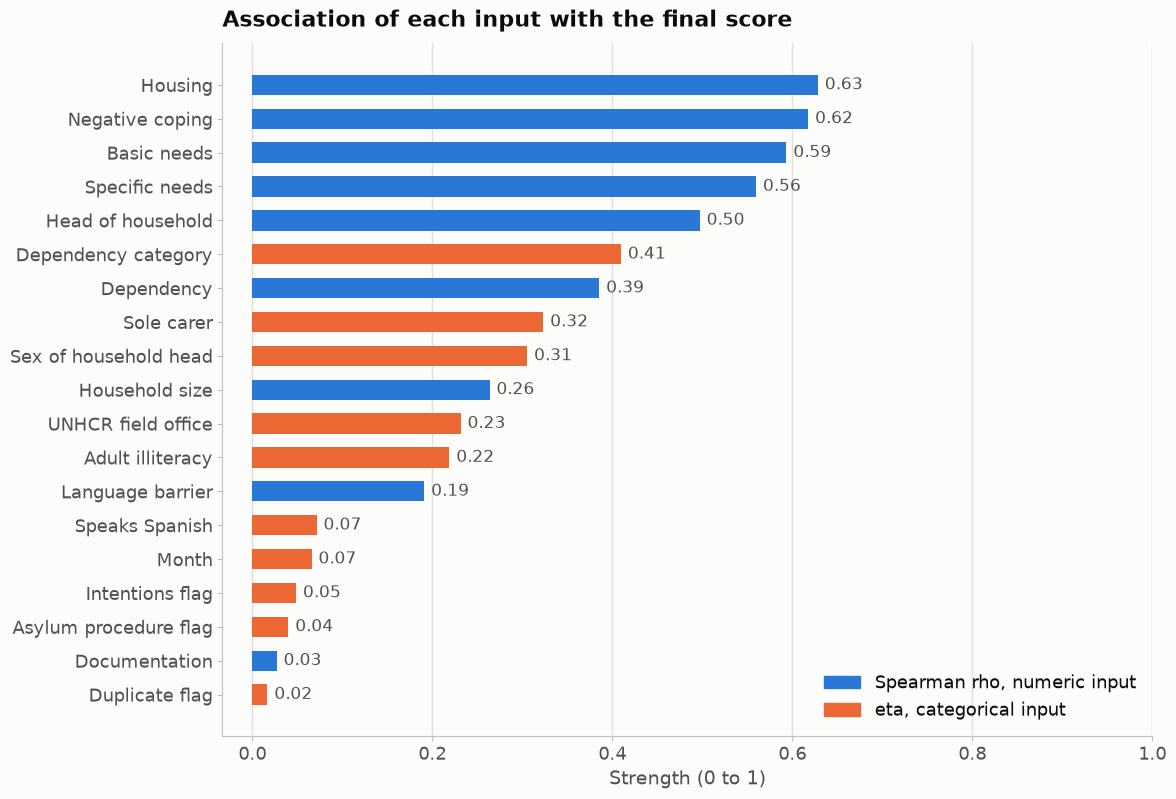

In [39]:
positions = np.arange(len(association))
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(
    positions,
    association["value"],
    height=0.6,
    color=[
        BLUE if measure == "Spearman rho" else ORANGE
        for measure in association["measure"]
    ],
)
for y, value in zip(positions, association["value"]):
    ax.annotate(
        f"{value:.2f}",
        (max(value, 0), y),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=12,
        color=INK_SECONDARY,
    )
ax.set_yticks(positions, association["input"])
ax.invert_yaxis()
ax.set_xlim(min(0.0, association["value"].min() - 0.05), 1.0)
ax.set(
    title="Association of each input with the final score", xlabel="Strength (0 to 1)"
)
ax.grid(axis="x")
ax.grid(visible=False, axis="y")
ax.legend(
    handles=[
        Patch(color=BLUE, label="Spearman rho, numeric input"),
        Patch(color=ORANGE, label="eta, categorical input"),
    ],
    loc="lower right",
)
save_figure(fig, "association_with_final_score")

In [40]:
as_categories = pd.DataFrame(
    {
        column: raw[column].round(2) if column in FACTORS else data[column]
        for column in inputs
    }
)
input_names = [ENGLISH_NAMES[column] for column in inputs]
input_association = pd.DataFrame(
    np.eye(len(inputs)), index=input_names, columns=input_names
)
for first, second in itertools.combinations(inputs, 2):
    value = cramers_v(as_categories[first], as_categories[second])
    input_association.loc[ENGLISH_NAMES[first], ENGLISH_NAMES[second]] = value
    input_association.loc[ENGLISH_NAMES[second], ENGLISH_NAMES[first]] = value
save_table(input_association.reset_index(names="input"), "input_association_matrix")
upper = np.triu(np.ones(input_association.shape, dtype=bool), k=1)
top_pairs = (
    input_association.where(upper)
    .stack()
    .sort_values(ascending=False)
    .head(10)
    .rename_axis(["first_input", "second_input"])
    .reset_index(name="cramers_v")
)
save_table(top_pairs, "input_association_top_pairs")

,first_input,second_input,cramers_v
0,Sex of household head,Sole carer,0.811909
1,Household size,Sole carer,0.743699
2,Household size,Sex of household head,0.717950
3,Dependency category,Sole carer,0.624515
4,Household size,Dependency category,0.600719
5,Dependency category,Sex of household head,0.585267
6,Basic needs,Negative coping,0.512916
7,Basic needs,Housing,0.470209
8,Head of household,Dependency,0.318344
9,Head of household,Specific needs,0.290191


In [41]:
spearman_inputs = raw[numeric_inputs].corr(method="spearman")
spearman_inputs = spearman_inputs.rename(index=ENGLISH_NAMES, columns=ENGLISH_NAMES)
save_table(spearman_inputs.reset_index(names="input"), "input_spearman_matrix")

,input,Head of household,Language barrier,Specific needs,Documentation,Basic needs,Housing,Negative coping,Dependency,Household size
0,Head of household,1.000000,-0.023682,0.301650,-0.008322,0.049553,0.043422,0.125972,0.268937,0.126648
1,Language barrier,-0.023682,1.000000,0.032839,0.017940,0.108301,0.076553,-0.063434,-0.100411,0.041890
2,Specific needs,0.301650,0.032839,1.000000,0.010059,0.097527,0.098058,0.127764,0.151471,0.123635
3,Documentation,-0.008322,0.017940,0.010059,1.000000,-0.073174,-0.024798,-0.044628,0.032611,-0.009628
4,Basic needs,0.049553,0.108301,0.097527,-0.073174,1.000000,0.469071,0.474412,0.145588,0.150059
5,Housing,0.043422,0.076553,0.098058,-0.024798,0.469071,1.000000,0.340672,0.076593,0.181684
6,Negative coping,0.125972,-0.063434,0.127764,-0.044628,0.474412,0.340672,1.000000,0.378566,0.180384
7,Dependency,0.268937,-0.100411,0.151471,0.032611,0.145588,0.076593,0.378566,1.000000,0.107580
8,Household size,0.126648,0.041890,0.123635,-0.009628,0.150059,0.181684,0.180384,0.107580,1.000000


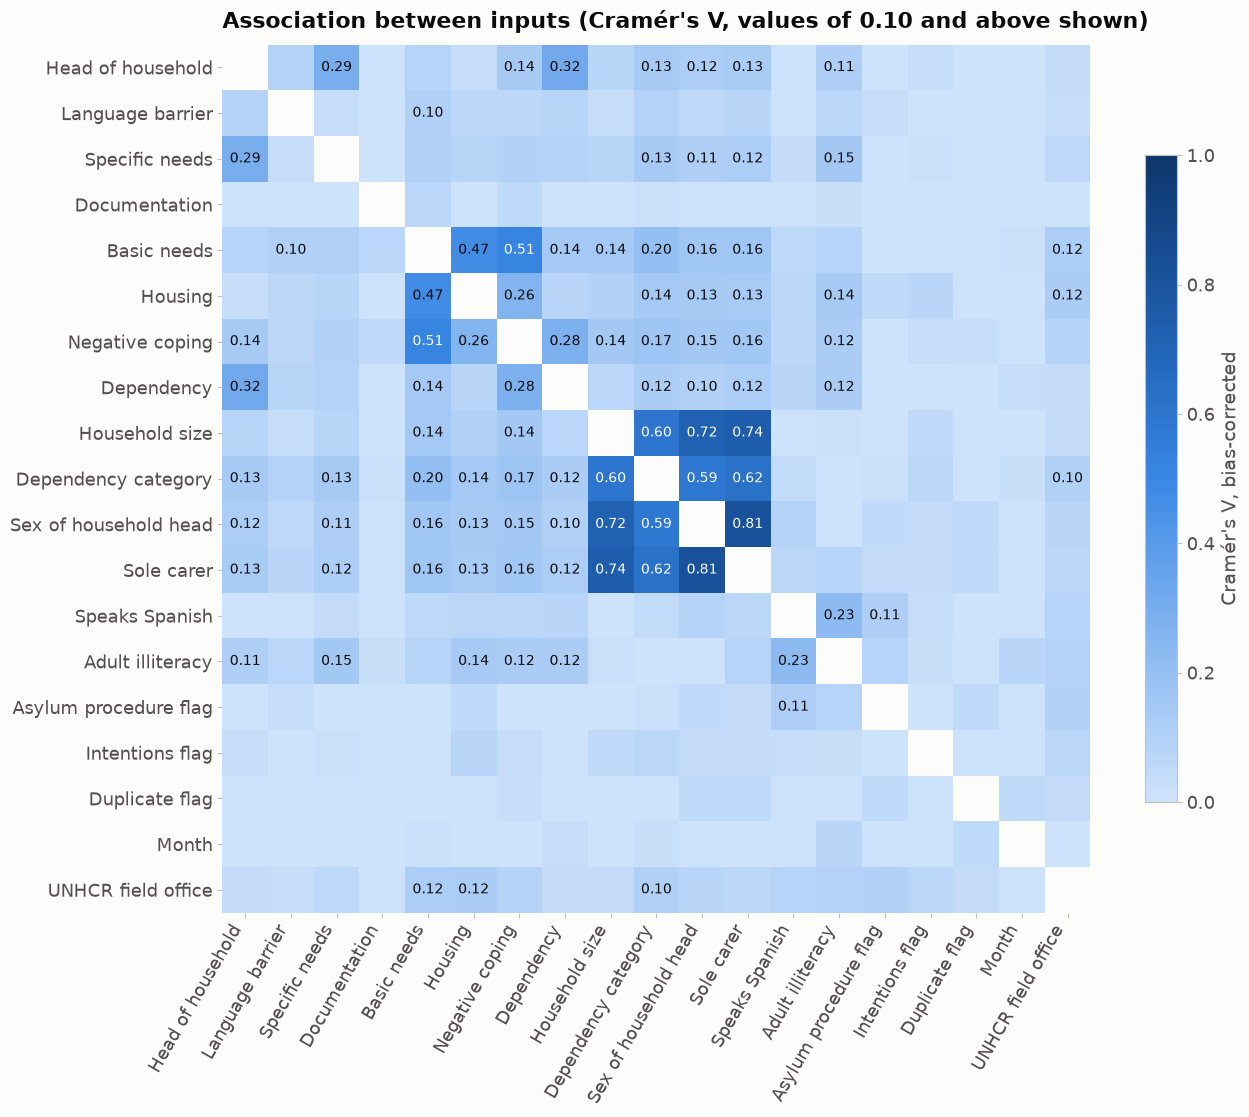

In [42]:
shown = input_association.to_numpy().copy()
np.fill_diagonal(shown, np.nan)
fig, ax = plt.subplots(figsize=(14, 12))
image = ax.imshow(shown, cmap=SEQUENTIAL, vmin=0, vmax=1)
for row, col in itertools.product(range(len(inputs)), repeat=2):
    value = shown[row, col]
    if row != col and value >= 0.1:
        ax.text(
            col,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color=SURFACE if value >= 0.5 else INK,
        )
ax.set_xticks(range(len(inputs)), input_names, rotation=60, ha="right")
ax.set_yticks(range(len(inputs)), input_names)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Association between inputs (Cramér's V, values of 0.10 and above shown)")
fig.colorbar(image, ax=ax, shrink=0.7, label="Cramér's V, bias-corrected")
save_figure(fig, "input_association_matrix")

## 6. Administrative flags

The flags against the final score, and descriptively against the eligibility
outcome.

In [43]:
included = raw["EligibilityTarget"].eq("INCLUSION")
all_households_rate = included.mean()
flag_score_frames, flag_rate_frames, flag_status_frames = [], [], []
for column in ADMIN_FLAGS:
    groups = data[column]
    flag_score_frames.append(
        final.groupby(groups, observed=True)
        .agg(n="size", mean="mean", median="median", std="std")
        .reset_index(names="level")
        .assign(flag=ENGLISH_NAMES[column])
    )
    flag_rate_frames.append(
        rate_table(included, groups).assign(flag=ENGLISH_NAMES[column])
    )
    flag_status_frames.append(
        pd.crosstab(groups, data["Elegibilidad"])
        .reset_index(names="level")
        .assign(flag=ENGLISH_NAMES[column])
    )
flag_scores = pd.concat(flag_score_frames, ignore_index=True)
flag_scores["small_group"] = flag_scores["n"] < SMALL_GROUP_N
save_table(
    flag_scores[["flag", "level", "n", "mean", "median", "std", "small_group"]],
    "flags_final_score",
)
flag_rates = pd.concat(flag_rate_frames, ignore_index=True)
save_table(
    flag_rates[
        ["flag", "group", "n", "count", "rate", "ci_low", "ci_high", "small_group"]
    ],
    "flags_inclusion_rate",
)
flag_status = pd.concat(flag_status_frames, ignore_index=True)
save_table(
    flag_status[["flag", "level", *VALUE_LABELS["Elegibilidad"].values()]],
    "flags_by_eligibility_status",
)

Elegibilidad,flag,level,Eligible,"Eligible, accelerated process",Waiting list,Not eligible,"Not eligible, stated intentions","Not eligible, duplicate registration"
0,Asylum procedure flag,-500,23,0,43,84,2,3
1,Asylum procedure flag,0,180,2,169,373,25,22
2,Asylum procedure flag,+500,2,0,4,8,0,0
3,Asylum procedure flag,Not applicable,209,11,235,467,25,13
4,Intentions flag,-500,18,0,9,28,1,0
5,Intentions flag,0,396,13,442,904,51,38
6,Duplicate flag,-500,15,0,10,21,1,1
7,Duplicate flag,0,399,13,441,911,51,37


In [44]:
any_negative = raw[ADMIN_FLAGS].eq(-500).any(axis=1)
reason_rows = []
for column, status in [
    ("ScoreIntenciones", "No Elegible por Intenciones"),
    ("ScoreDuplicidad", "No Elegible por Duplicidad"),
]:
    flagged = raw[column].eq(-500)
    reason = raw["Elegibilidad"].eq(status)
    reason_rows.append(
        {
            "flag": ENGLISH_NAMES[column],
            "matching_status": VALUE_LABELS["Elegibilidad"][status],
            "flagged": int(flagged.sum()),
            "flagged_with_matching_status": int((flagged & reason).sum()),
            "matching_status_recorded": int(reason.sum()),
            "matching_status_without_flag": int((reason & ~flagged).sum()),
            "flagged_and_included": int((flagged & included).sum()),
        }
    )
reason_rows += [
    {
        "flag": ENGLISH_NAMES["ScoreCOMAR_PIL"],
        "matching_status": "no specific status",
        "flagged": int(raw["ScoreCOMAR_PIL"].eq(-500).sum()),
        "flagged_and_included": int((raw["ScoreCOMAR_PIL"].eq(-500) & included).sum()),
    },
    {
        "flag": "Any of the three flags at -500",
        "matching_status": "",
        "flagged": int(any_negative.sum()),
        "flagged_and_included": int((any_negative & included).sum()),
    },
]
flag_reasons = save_table(pd.DataFrame(reason_rows), "flags_vs_exclusion_reason")
negative_flag_rates = rate_table(
    included, any_negative.map({True: "At least one -500 flag", False: "No -500 flag"})
)
save_table(negative_flag_rates, "inclusion_rate_by_negative_flag")
flag_reasons

,flag,matching_status,flagged,flagged_with_matching_status,matching_status_recorded,matching_status_without_flag,flagged_and_included
0,Intentions flag,"Not eligible, stated intentions",56,1.0,52.0,51.0,18
1,Duplicate flag,"Not eligible, duplicate registration",48,1.0,38.0,37.0,15
2,Asylum procedure flag,no specific status,155,NaN,NaN,NaN,23
3,Any of the three flags at -500,,251,NaN,NaN,NaN,56


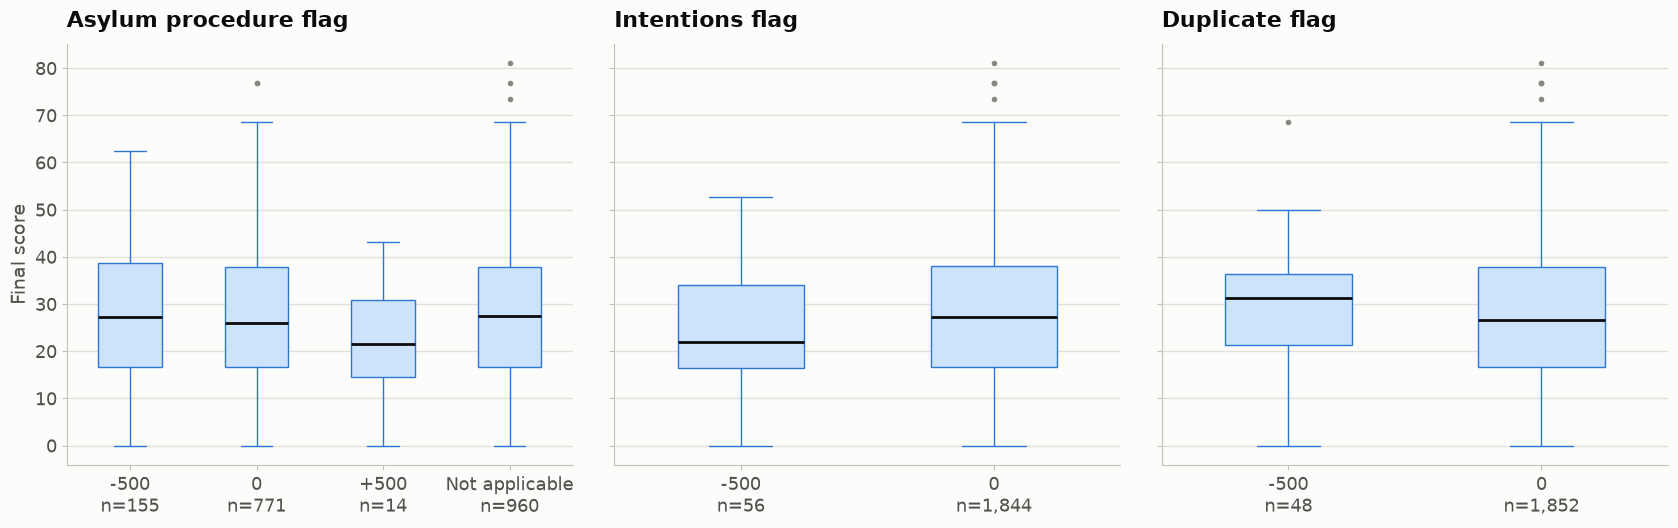

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
for ax, column in zip(axes, ADMIN_FLAGS):
    groups = data[column]
    levels = [level for level in groups.cat.categories if groups.eq(level).any()]
    samples = [final[groups == level] for level in levels]
    ax.boxplot(
        samples,
        widths=0.5,
        patch_artist=True,
        boxprops={"facecolor": "#cde2fb", "edgecolor": BLUE},
        medianprops={"color": INK, "linewidth": 2},
        whiskerprops={"color": BLUE},
        capprops={"color": BLUE},
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": MUTED,
            "markeredgecolor": "none",
        },
    )
    ax.set_xticks(
        range(1, len(levels) + 1),
        [f"{level}\nn={len(sample):,}" for level, sample in zip(levels, samples)],
    )
    ax.set(title=ENGLISH_NAMES[column])
axes[0].set_ylabel("Final score")
fig.tight_layout()
save_figure(fig, "flags_final_score")

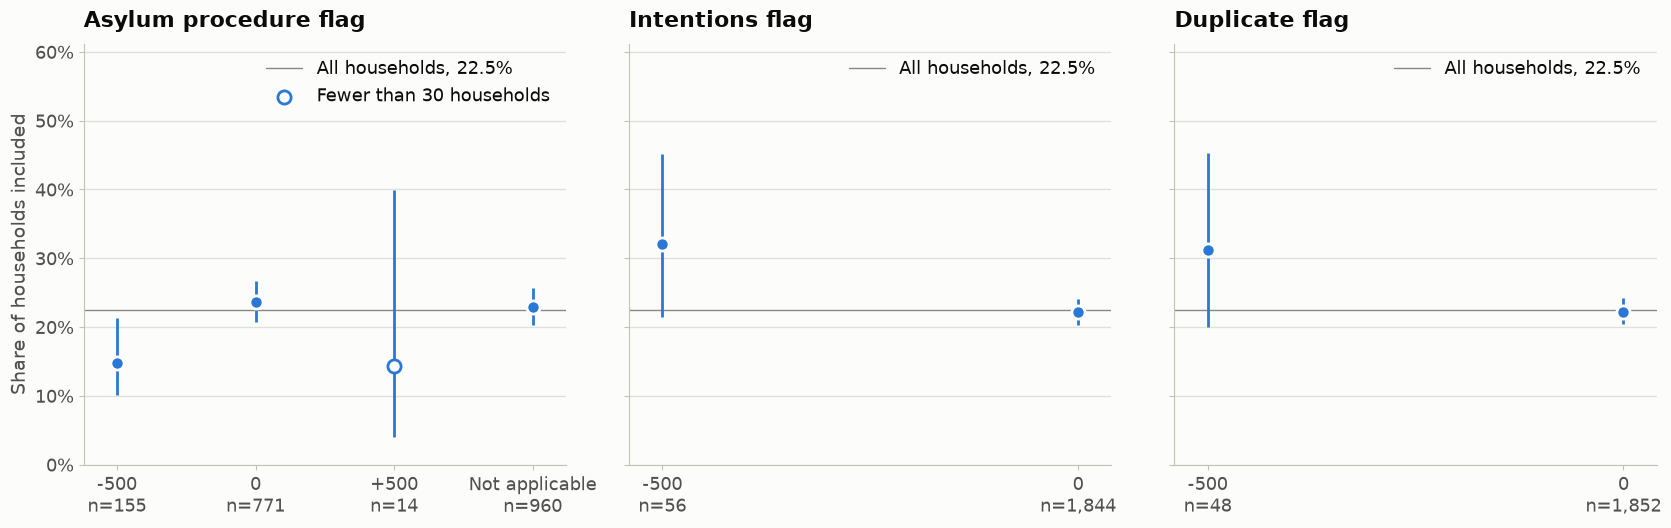

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
for ax, (flag, rates) in zip(axes, flag_rates.groupby("flag", sort=False)):
    plot_rates(ax, rates.reset_index(drop=True), all_households_rate)
    ax.set(title=flag)
axes[0].set_ylabel("Share of households included")
fig.tight_layout()
save_figure(fig, "flags_inclusion_rate")

## 7. Eligibility, descriptive only

Inclusion rates with Wilson 95% intervals. No model is fitted here and none of
these numbers is a performance benchmark.

In [47]:
by_category = rate_table(included, data["Vulnerability_Category"])
by_month = rate_table(included, data["month"])
by_office = rate_table(included, data["OficinaACNUR"])
inclusion_rates = pd.concat(
    [
        rate_table(included, pd.Series("All households", index=raw.index)).assign(
            breakdown="All households"
        ),
        by_category.assign(breakdown="Vulnerability category"),
        by_month.assign(breakdown="Month"),
        by_office.assign(breakdown="UNHCR field office"),
    ],
    ignore_index=True,
)
save_table(
    inclusion_rates[
        ["breakdown", "group", "n", "count", "rate", "ci_low", "ci_high", "small_group"]
    ],
    "inclusion_rate_by_group",
)

,breakdown,group,n,count,rate,ci_low,ci_high,small_group
0,All households,All households,1900,427,0.224737,0.206534,0.244050,False
1,Vulnerability category,Low,775,162,0.209032,0.181875,0.239060,False
2,Vulnerability category,Moderate,394,88,0.223350,0.185008,0.267035,False
3,Vulnerability category,High,612,153,0.250000,0.217325,0.285794,False
4,Vulnerability category,Severe,119,24,0.201681,0.139442,0.282577,False
5,Month,2023-06,84,3,0.035714,0.012220,0.099817,False
6,Month,2023-07,160,7,0.043750,0.021352,0.087543,False
7,Month,2023-08,166,48,0.289157,0.225575,0.362276,False
8,Month,2023-09,121,29,0.239669,0.172371,0.322989,False
9,Month,2023-10,138,44,0.318841,0.246897,0.400597,False


In [48]:
status_by_category = pd.crosstab(data["Elegibilidad"], data["Vulnerability_Category"])
status_share = status_by_category / status_by_category.sum()
status_by_category = (
    status_by_category.stack()
    .rename("n")
    .to_frame()
    .join(status_share.stack().rename("share_of_category"))
    .rename_axis(["eligibility_status", "vulnerability_category"])
    .reset_index()
)
save_table(status_by_category, "eligibility_status_by_category")

,eligibility_status,vulnerability_category,n,share_of_category
0,Eligible,Low,154,0.198710
1,Eligible,Moderate,85,0.215736
2,Eligible,High,151,0.246732
3,Eligible,Severe,24,0.201681
4,"Eligible, accelerated process",Low,8,0.010323
5,"Eligible, accelerated process",Moderate,3,0.007614
6,"Eligible, accelerated process",High,2,0.003268
7,"Eligible, accelerated process",Severe,0,0.000000
8,Waiting list,Low,205,0.264516
9,Waiting list,Moderate,89,0.225888


In [49]:
eligibility_rows = []
for column in ["Vulnerability_Category", "month", "OficinaACNUR", *ADMIN_FLAGS]:
    table = pd.crosstab(data[column], data["EligibilityTarget"])
    eligibility_rows.append(
        {
            "variable": ENGLISH_NAMES[column],
            "measure": "Cramér's V, bias-corrected",
            "value": cramers_v(data[column], data["EligibilityTarget"]),
            "test": "chi-square",
            "p_value": stats.chi2_contingency(table).pvalue,
        }
    )
eligibility_rows.append(
    {
        "variable": "Final score",
        "measure": "point-biserial r",
        "value": stats.pointbiserialr(included, final).statistic,
        "test": "Mann-Whitney U",
        "p_value": stats.mannwhitneyu(final[included], final[~included]).pvalue,
    }
)
eligibility_association = save_table(
    pd.DataFrame(eligibility_rows), "eligibility_association"
)
score_by_target = (
    final.groupby(data["EligibilityTarget"], observed=True)
    .describe()[["count", "mean", "25%", "50%", "75%"]]
    .rename(columns={"count": "n", "25%": "q1", "50%": "median", "75%": "q3"})
    .reset_index(names="eligibility_target")
)
save_table(score_by_target, "final_score_by_eligibility")
eligibility_association

,variable,measure,value,test,p_value
0,Vulnerability category,"Cramér's V, bias-corrected",0.019264,chi-square,2.949724e-01
1,Month,"Cramér's V, bias-corrected",0.313812,chi-square,1.355921e-35
2,UNHCR field office,"Cramér's V, bias-corrected",0.000000,chi-square,8.653753e-01
3,Asylum procedure flag,"Cramér's V, bias-corrected",0.042302,chi-square,9.369885e-02
4,Intentions flag,"Cramér's V, bias-corrected",0.033220,chi-square,1.102362e-01
5,Duplicate flag,"Cramér's V, bias-corrected",0.024890,chi-square,1.934856e-01
6,Final score,point-biserial r,0.034249,Mann-Whitney U,6.323208e-02


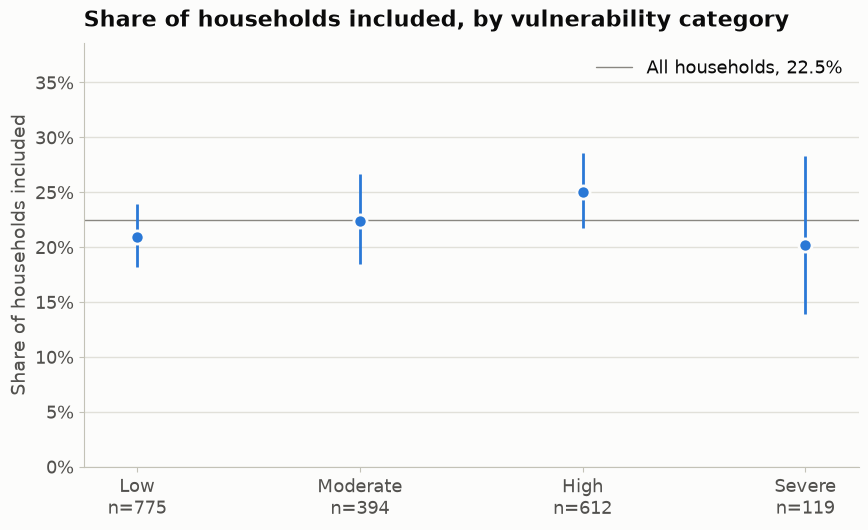

In [50]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_rates(ax, by_category, all_households_rate)
ax.set(
    title="Share of households included, by vulnerability category",
    ylabel="Share of households included",
)
save_figure(fig, "inclusion_rate_by_category")

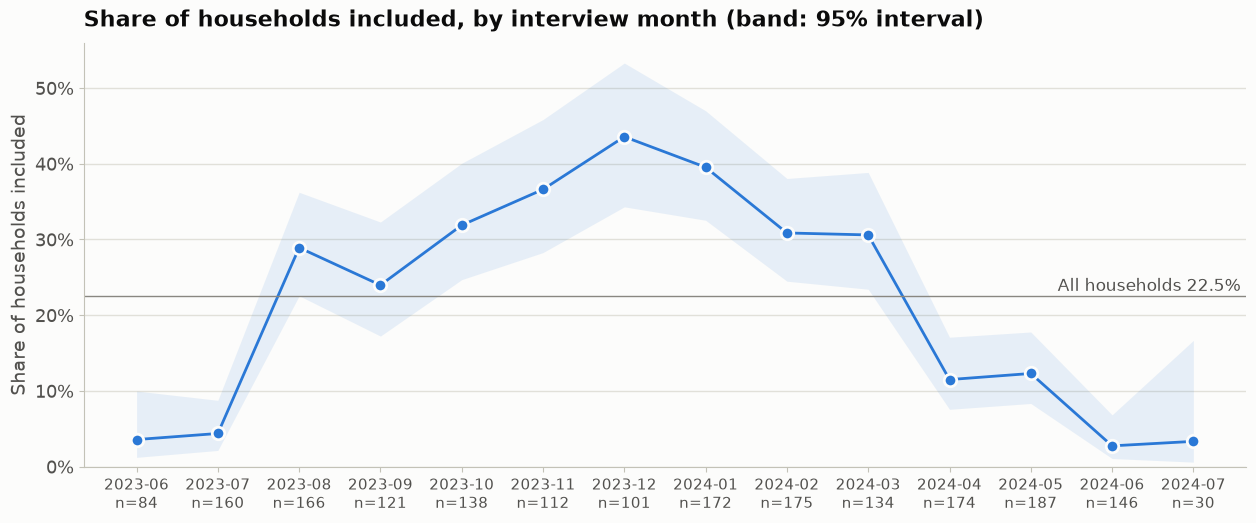

In [51]:
x = np.arange(len(by_month))
fig, ax = plt.subplots(figsize=(15, 5.5))
ax.fill_between(
    x, by_month["ci_low"], by_month["ci_high"], color=BLUE, alpha=0.1, linewidth=0
)
ax.plot(
    x,
    by_month["rate"],
    color=BLUE,
    marker="o",
    markersize=9,
    markeredgecolor=SURFACE,
    markeredgewidth=2,
)
ax.axhline(all_households_rate, color=MUTED, linewidth=1)
ax.annotate(
    f"All households {all_households_rate:.1%}",
    xy=(1, all_households_rate),
    xycoords=("axes fraction", "data"),
    xytext=(-4, 4),
    textcoords="offset points",
    ha="right",
    fontsize=12,
    color=INK_SECONDARY,
)
ax.set_xticks(
    x,
    [f"{month}\nn={n}" for month, n in zip(by_month["group"], by_month["n"])],
    fontsize=11,
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(bottom=0)
ax.set(
    title="Share of households included, by interview month (band: 95% interval)",
    ylabel="Share of households included",
)
save_figure(fig, "inclusion_rate_by_month")

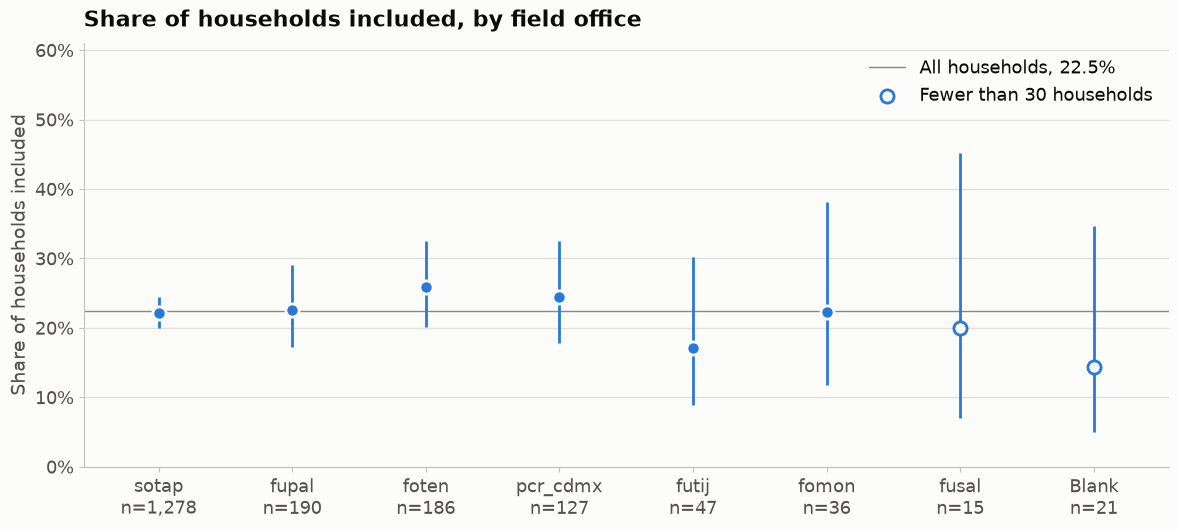

In [52]:
fig, ax = plt.subplots(figsize=(14, 5.5))
plot_rates(ax, by_office, all_households_rate)
ax.set(
    title="Share of households included, by field office",
    ylabel="Share of households included",
)
save_figure(fig, "inclusion_rate_by_office")

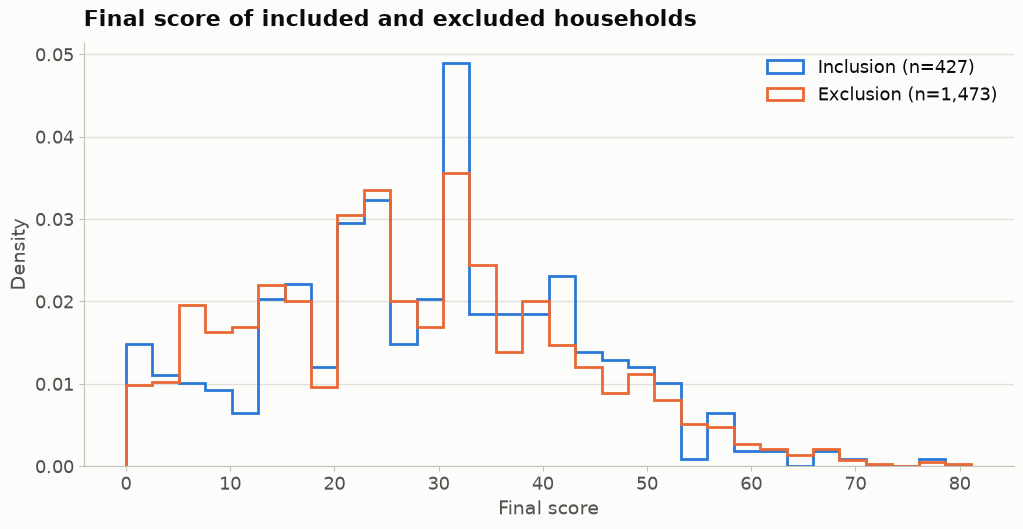

In [53]:
bins = np.linspace(0, final.max(), 33)
fig, ax = plt.subplots(figsize=(12, 5.5))
for label, color in [("Inclusion", BLUE), ("Exclusion", ORANGE)]:
    values = final[data["EligibilityTarget"] == label]
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2,
        color=color,
        label=f"{label} (n={len(values):,})",
    )
ax.set(
    title="Final score of included and excluded households",
    xlabel="Final score",
    ylabel="Density",
)
ax.legend()
save_figure(fig, "final_score_by_eligibility")

## 8. Time and office

In [54]:
volume_month = data["month"].value_counts().sort_index()
volume_office = data["OficinaACNUR"].value_counts(sort=False)
interview_volume = pd.concat(
    [
        pd.DataFrame(
            {
                "breakdown": "Month",
                "group": volume_month.index,
                "n": volume_month.to_numpy(),
            }
        ),
        pd.DataFrame(
            {
                "breakdown": "UNHCR field office",
                "group": volume_office.index.astype(str),
                "n": volume_office.to_numpy(),
            }
        ),
    ],
    ignore_index=True,
)
interview_volume["share"] = interview_volume["n"] / len(raw)
interview_volume["small_group"] = interview_volume["n"] < SMALL_GROUP_N
save_table(interview_volume, "interviews_by_month_and_office")
save_table(
    pd.crosstab(data["OficinaACNUR"], data["month"]).reset_index(names="office"),
    "interviews_by_office_and_month",
)

month,office,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07
0,sotap,58,103,115,77,97,71,68,113,114,94,119,130,100,19
1,fupal,9,15,14,11,12,8,12,17,22,13,19,15,17,6
2,foten,9,18,17,15,12,10,8,20,22,11,14,17,11,2
3,pcr_cdmx,4,16,8,8,10,10,6,14,10,7,12,11,10,1
4,futij,2,3,4,2,3,9,0,4,3,2,3,7,4,1
5,fomon,0,1,4,3,2,3,3,4,2,5,4,4,1,0
6,fusal,0,1,2,1,0,1,2,0,1,2,0,1,3,1
7,Blank,2,3,2,4,2,0,2,0,1,0,3,2,0,0


In [55]:
def score_summary(groups: pd.Series, breakdown: str) -> pd.DataFrame:
    """Final score quartiles per group."""
    summary = (
        final.groupby(groups, observed=True)
        .describe()[["count", "mean", "25%", "50%", "75%"]]
        .rename(columns={"count": "n", "25%": "q1", "50%": "median", "75%": "q3"})
        .reset_index(names="group")
    )
    summary["n"] = summary["n"].astype(int)
    summary["small_group"] = summary["n"] < SMALL_GROUP_N
    return summary.assign(breakdown=breakdown)


score_by_month = score_summary(data["month"], "Month")
score_by_office = score_summary(data["OficinaACNUR"], "UNHCR field office")
save_table(
    pd.concat([score_by_month, score_by_office], ignore_index=True),
    "final_score_by_month_and_office",
)
month_order = pd.factorize(raw["month"], sort=True)[0]
month_trend = stats.spearmanr(month_order, final)
time_office_tests = pd.DataFrame(
    [
        (
            "Kruskal-Wallis, final score across months",
            "eta",
            correlation_ratio(data["month"], final),
            stats.kruskal(*[v for _, v in final.groupby(data["month"])]).pvalue,
        ),
        (
            "Spearman, month order against final score",
            "rho",
            month_trend.statistic,
            month_trend.pvalue,
        ),
        (
            "Kruskal-Wallis, final score across offices",
            "eta",
            correlation_ratio(data["OficinaACNUR"], final),
            stats.kruskal(
                *[v for _, v in final.groupby(data["OficinaACNUR"], observed=True)]
            ).pvalue,
        ),
    ],
    columns=["test", "effect_measure", "effect_size", "p_value"],
)
save_table(time_office_tests, "time_office_tests")
category_mix = pd.crosstab(
    data["month"], data["Vulnerability_Category"], normalize="index"
)
save_table(category_mix.reset_index(names="month"), "category_mix_by_month")
time_office_tests

,test,effect_measure,effect_size,p_value
0,"Kruskal-Wallis, final score across months",eta,0.065637,9.671084e-01
1,"Spearman, month order against final score",rho,0.010520,6.467569e-01
2,"Kruskal-Wallis, final score across offices",eta,0.231270,2.223265e-22


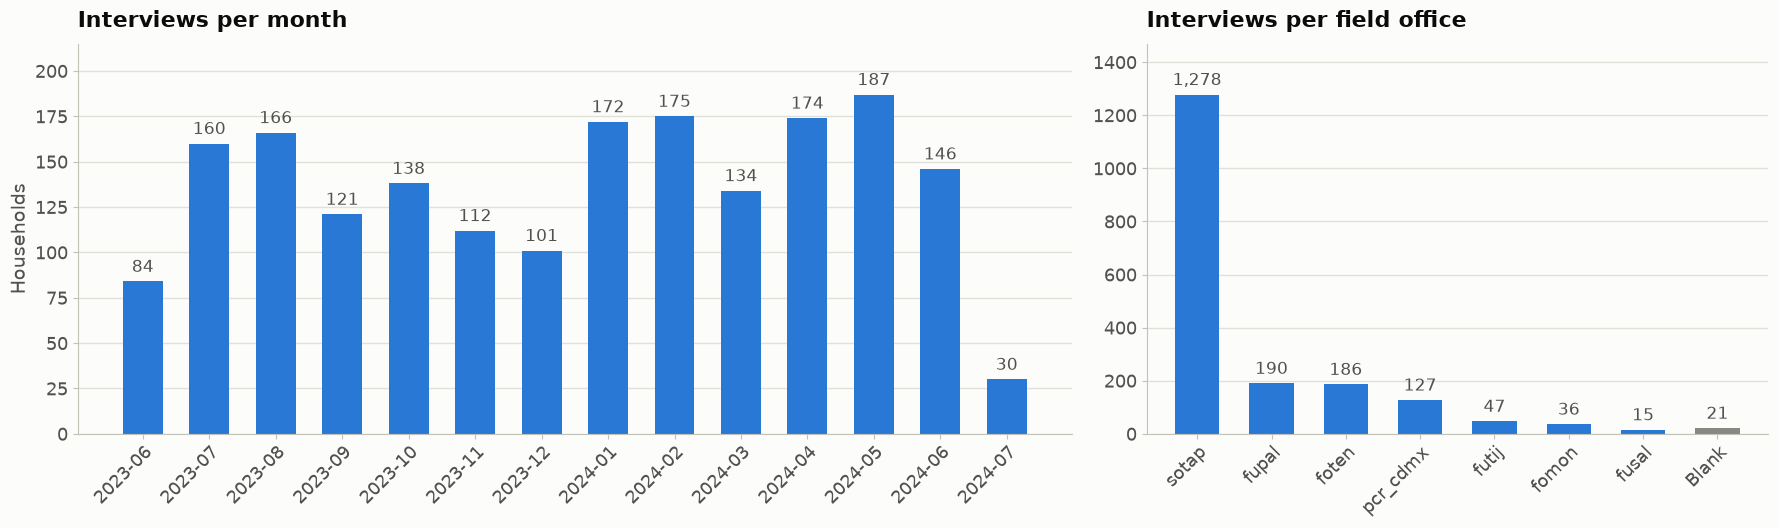

In [56]:
fig, axes = plt.subplots(
    1, 2, figsize=(18, 5.5), gridspec_kw={"width_ratios": [1.6, 1]}
)
plot_counts(axes[0], volume_month)
axes[0].set(title="Interviews per month", ylabel="Households")
plot_counts(axes[1], volume_office)
axes[1].set(title="Interviews per field office")
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
fig.tight_layout()
save_figure(fig, "interviews_by_month_and_office")

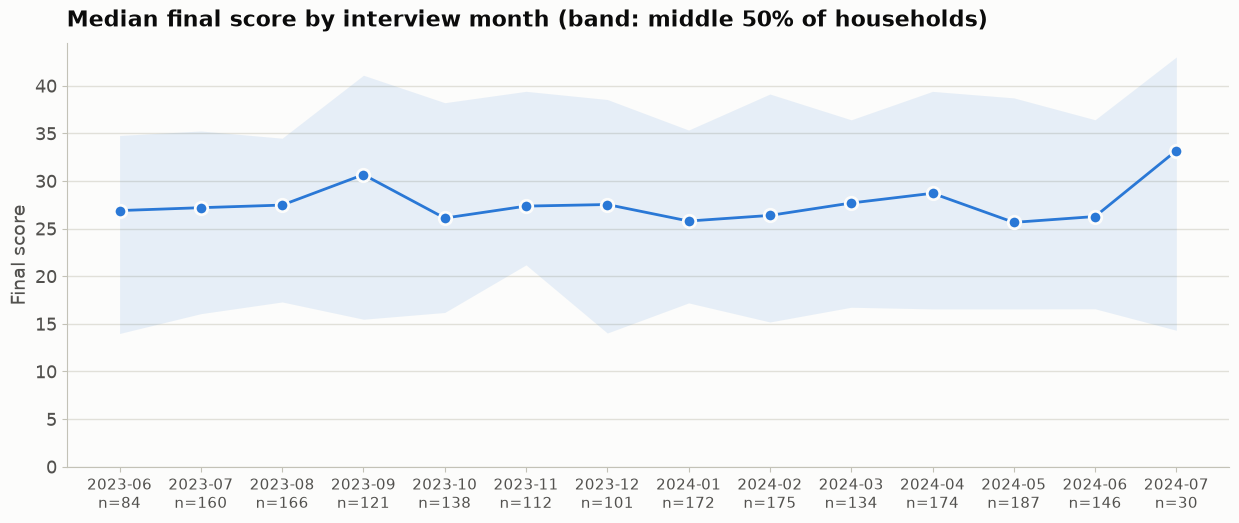

In [57]:
x = np.arange(len(score_by_month))
fig, ax = plt.subplots(figsize=(15, 5.5))
ax.fill_between(
    x, score_by_month["q1"], score_by_month["q3"], color=BLUE, alpha=0.1, linewidth=0
)
ax.plot(
    x,
    score_by_month["median"],
    color=BLUE,
    marker="o",
    markersize=9,
    markeredgecolor=SURFACE,
    markeredgewidth=2,
)
ax.set_xticks(
    x,
    [
        f"{month}\nn={n}"
        for month, n in zip(score_by_month["group"], score_by_month["n"])
    ],
    fontsize=11,
)
ax.set_ylim(bottom=0)
ax.set(
    title="Median final score by interview month (band: middle 50% of households)",
    ylabel="Final score",
)
save_figure(fig, "final_score_by_month")

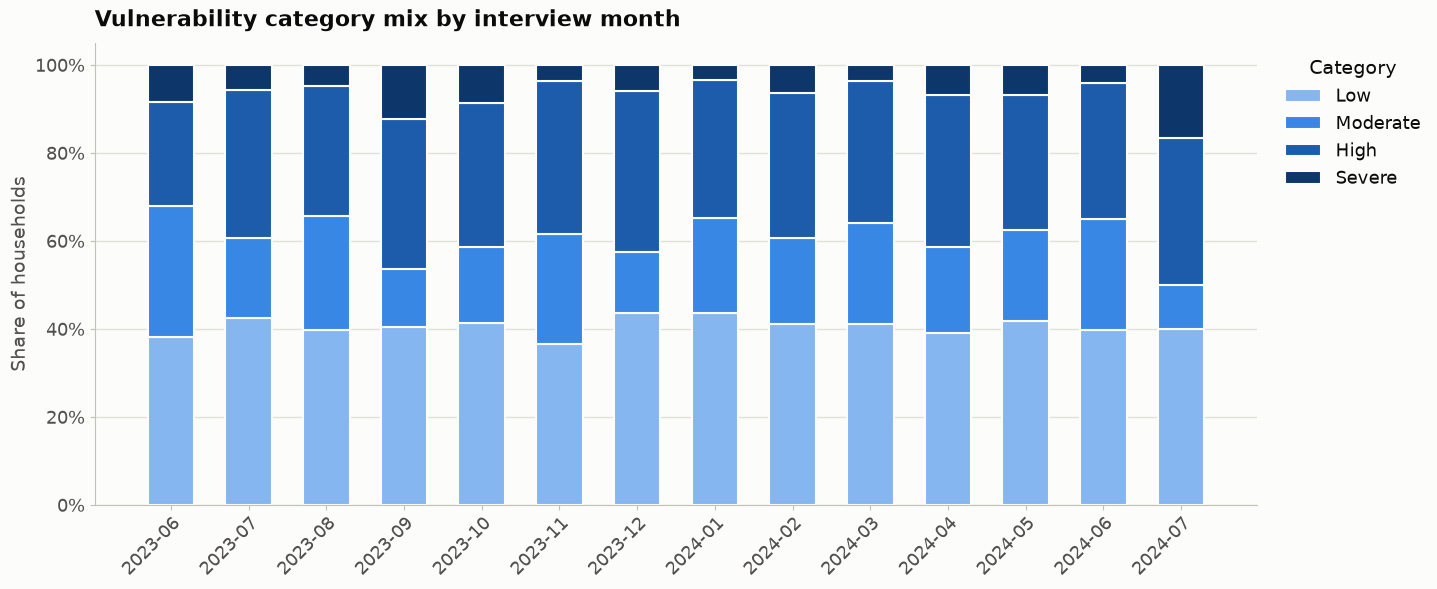

In [58]:
months = category_mix.index.tolist()
fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(months))
for label, color in zip(category_labels, CATEGORY_COLORS):
    ax.bar(
        months,
        category_mix[label],
        bottom=bottom,
        width=0.6,
        color=color,
        edgecolor=SURFACE,
        linewidth=1.5,
        label=label,
    )
    bottom += category_mix[label].to_numpy()
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set(
    title="Vulnerability category mix by interview month", ylabel="Share of households"
)
ax.legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
save_figure(fig, "category_mix_by_month")

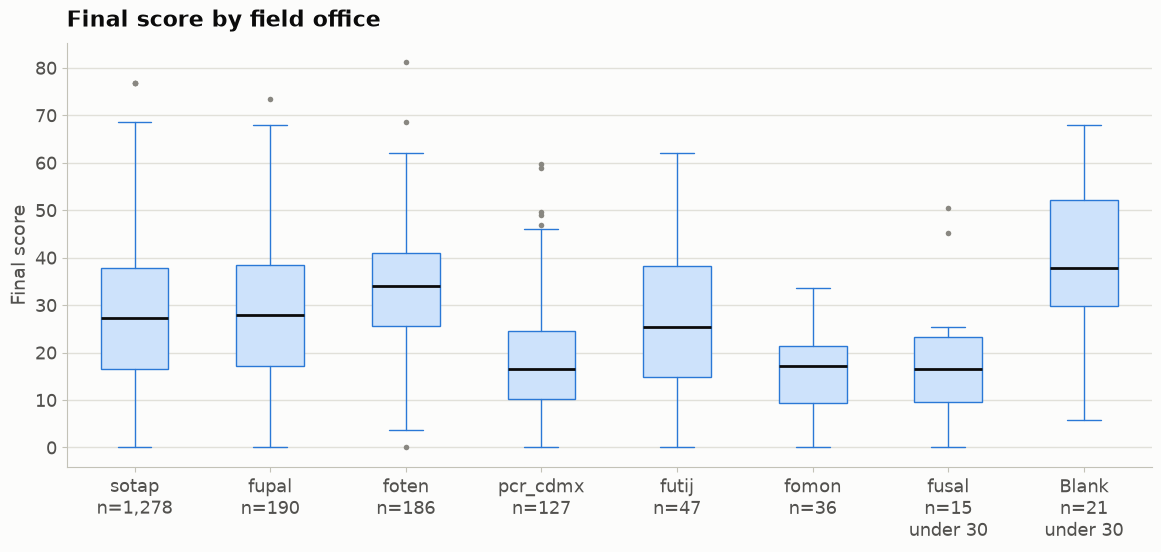

In [59]:
offices = [office for office in data["OficinaACNUR"].cat.categories]
samples = [final[data["OficinaACNUR"] == office] for office in offices]
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.boxplot(
    samples,
    widths=0.5,
    patch_artist=True,
    boxprops={"facecolor": "#cde2fb", "edgecolor": BLUE},
    medianprops={"color": INK, "linewidth": 2},
    whiskerprops={"color": BLUE},
    capprops={"color": BLUE},
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": MUTED,
        "markeredgecolor": "none",
    },
)
ax.set_xticks(
    range(1, len(offices) + 1),
    [
        f"{office}\nn={len(sample):,}"
        + ("\nunder 30" if len(sample) < SMALL_GROUP_N else "")
        for office, sample in zip(offices, samples)
    ],
)
ax.set(title="Final score by field office", ylabel="Final score")
save_figure(fig, "final_score_by_office")

## 9. Implications for modelling

In [60]:
roles = {
    **{
        column: (
            "Input, feature set A",
            "The final score is an exact function of these eight",
        )
        for column in FACTORS
    },
    **{
        column: (
            "Candidate input, feature set B",
            "Not in the score formula; weakly associated with the factors",
        )
        for column in HOUSEHOLD_ATTRIBUTES
    },
    **{
        column: ("Excluded from the score model", "Not in the score formula")
        for column in ADMIN_FLAGS
    },
    **{
        column: (
            "Excluded from the score model",
            "Where and when an interview took place should not determine need",
        )
        for column in INTERVIEW_RECORD
    },
    **{
        column: ("Excluded, leakage", "Computed from the factor scores")
        for column in AGGREGATED_SCORES
    },
    **{column: ("Excluded, outcome", "Never a model input") for column in OUTCOMES},
}
model_inputs = pd.DataFrame(
    [
        {
            "column": column,
            "english_name": ENGLISH_NAMES[column],
            "group": group_of[column],
            "phase_2_role": role,
            "reason": reason,
        }
        for column, (role, reason) in roles.items()
    ]
)
save_table(model_inputs, "model_inputs")

,column,english_name,group,phase_2_role,reason
0,Demographics.HH.Head,Head of household,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
1,Demographics.Language,Language barrier,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
2,Demographics.Profiles,Specific needs,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
3,Demographics.Documentation,Documentation,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
4,Needs_and_Coping.BasicNeeds,Basic needs,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
5,Needs_and_Coping.Housing,Housing,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
6,Needs_and_Coping.Neg.mechanism,Negative coping,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
7,Needs_and_Coping.Dependency,Dependency,Scorecard factor score,"Input, feature set A",The final score is an exact function of these ...
8,NumIntegrantes,Household size,Household attribute,"Candidate input, feature set B",Not in the score formula; weakly associated wi...
9,dependencyCategory,Dependency category,Household attribute,"Candidate input, feature set B",Not in the score formula; weakly associated wi...


In [61]:
all_households = inclusion_rates[inclusion_rates["breakdown"] == "All households"].iloc[
    0
]
eligibility_v = eligibility_association.set_index("variable")["value"]
negative_rates = negative_flag_rates.set_index("group")["rate"]
duplicate_reason = flag_reasons.set_index("flag").loc[ENGLISH_NAMES["ScoreDuplicidad"]]
update_key_stats(
    "phase_1_data_exploration",
    {
        "households": len(raw),
        "columns": raw.shape[1],
        "block_score_formula_max_abs_error": float(
            candidates.query("form == 'Recovered formula' and target != 'Final score'")[
                "max_abs_error"
            ].max()
        ),
        "final_score_formula_max_abs_error": float(
            candidates.query("form == 'Recovered formula' and target == 'Final score'")[
                "max_abs_error"
            ].iloc[0]
        ),
        "vulnerability_index_formula_max_abs_error": float(
            (index - scorecard.vulnerability_index(raw)).abs().max()
        ),
        "final_score_block_weights": [round(weight_d, 6), round(weight_n, 6)],
        "final_score_minus_block_sum_range": [round(gap.min(), 2), round(gap.max(), 2)],
        "final_score_possible_range": [0.0, round(float(grid_final.max()), 2)],
        "final_score_observed_max": round(final.max(), 2),
        "category_index_cutpoints": list(scorecard.CATEGORY_CUTPOINTS),
        "category_final_score_cutpoints": [
            round(scorecard.final_from_index(cutpoint), 2)
            for cutpoint in scorecard.CATEGORY_CUTPOINTS
        ],
        "category_reproduced": int(matches.sum()),
        "category_not_reproduced": int((~matches).sum()),
        "distinct_factor_combinations": len(raw[FACTORS].drop_duplicates()),
        "possible_factor_combinations": len(grid),
        "interaction_mean_points": round(interaction.mean(), 2),
        "inclusion_rate_all_households": round(all_households["rate"], 4),
        "inclusion_rate_all_households_ci": [
            round(all_households["ci_low"], 4),
            round(all_households["ci_high"], 4),
        ],
        "inclusion_rate_by_category": {
            row.group: round(row.rate, 4) for row in by_category.itertuples()
        },
        "inclusion_rate_by_month_range": [
            round(by_month["rate"].min(), 4),
            round(by_month["rate"].max(), 4),
        ],
        "cramers_v_category_vs_eligibility": round(
            eligibility_v["Vulnerability category"], 3
        ),
        "cramers_v_month_vs_eligibility": round(eligibility_v["Month"], 3),
        "inclusion_rate_with_negative_flag": round(
            negative_rates["At least one -500 flag"], 4
        ),
        "inclusion_rate_without_negative_flag": round(
            negative_rates["No -500 flag"], 4
        ),
        "duplicate_flagged": int(duplicate_reason["flagged"]),
        "duplicate_flagged_with_duplicate_status": int(
            duplicate_reason["flagged_with_matching_status"]
        ),
        "final_score_month_trend_p_value": round(month_trend.pvalue, 3),
    },
)